# Speech Emotion Recognition — Kelompok 1

Struktur notebook:
1. Preprocessing audio (load, trim, normalize, fix duration)
2. Framing & Windowing (demonstrasi konsep dari slide, dikaitkan dengan
   parameter yang dipakai librosa secara internal)
3. Ekstraksi Fitur (domain waktu, domain frekuensi, MFCC, Mel Spectrogram)
   — setiap tahap divisualisasikan untuk SEMUA kategori emosi
4. Training & Evaluasi (SVM, Random Forest pada 3 skenario fitur, CNN)
5. Justifikasi detail arsitektur CNN (kenapa Conv2D, kernel 3x3, pooling, dst)
6. Ekspor model `.pkl` untuk Streamlit
7. **Analisis** — bagian ini SENGAJA dikosongkan strukturnya saja (judul +
   pertanyaan pemandu), untuk diisi setelah kalian menjalankan notebook dan
   melihat hasil aktualnya.

**Struktur folder yang dibutuhkan (hasil split 80/20 berbasis aktor):**
```
dataset_split/
├── train/
│   ├── SAD/*.wav
│   ├── HAPPY/*.wav
│   └── ...
└── test/
    ├── SAD/*.wav
    ├── HAPPY/*.wav
    └── ...
```

## 0. Install & Import Library

In [1]:
# Jalankan sekali saja jika library belum terpasang
# !pip install librosa pandas numpy matplotlib seaborn tqdm scikit-learn tensorflow joblib

import os
import glob
import pickle
import joblib
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
print("Semua library berhasil di-import.")

Semua library berhasil di-import.


## 1. Konfigurasi

In [2]:
BASE_DIR       = "dataset_split"   # folder hasil split train/test
SR             = 22050             # sample rate target saat load audio (Hz)
N_MFCC         = 13                # jumlah koefisien MFCC sesuai tugas
N_MELS         = 128               # jumlah mel-band untuk spectrogram CNN
MAX_PAD_LEN    = 174                # panjang frame tetap mel-spectrogram (~4 detik)
FIXED_DURATION = 4.0                # durasi tetap (detik) hasil preprocessing audio
TOP_DB         = 25                # ambang batas trimming silence

# Parameter framing (sesuai konsep slide): frame_length & hop_length dalam SAMPEL
FRAME_LENGTH = 2048   # jumlah sampel per frame (~93 ms pada SR=22050 Hz)
HOP_LENGTH   = 512    # jarak antar awal frame -> overlap = FRAME_LENGTH - HOP_LENGTH = 1536 sampel

print("Konfigurasi siap.")
print(f"Durasi per frame  : {FRAME_LENGTH/SR*1000:.1f} ms")
print(f"Hop antar frame   : {HOP_LENGTH/SR*1000:.1f} ms")
print(f"Overlap per frame : {(FRAME_LENGTH-HOP_LENGTH)/SR*1000:.1f} ms "
      f"({(FRAME_LENGTH-HOP_LENGTH)/FRAME_LENGTH*100:.0f}% dari frame)")

Konfigurasi siap.
Durasi per frame  : 92.9 ms
Hop antar frame   : 23.2 ms
Overlap per frame : 69.7 ms (75% dari frame)


Frame umum berukuran 1024–2048 sampel dengan hop 256–512, dan overlap idealnya
1/2–2/3 dari panjang frame agar perubahan halus sinyal (terutama untuk ucapan
yang non-stasioner) tidak hilang. Konfigurasi `FRAME_LENGTH=2048, HOP_LENGTH=512`
di atas menghasilkan overlap 75% (1536/2048), sedikit lebih besar dari rentang
1/2–1/3 yang dicontohkan di slide — ini sengaja dipilih agar resolusi temporal
MFCC/Mel Spectrogram lebih halus, dengan trade-off komputasi sedikit lebih berat.
Jika ingin persis meniru slide (overlap 50%), ubah `HOP_LENGTH = FRAME_LENGTH // 2 = 1024`.

## 2. Preprocessing Audio

Proses **sampling**,
**quantization**, dan **coding** sudah dilakukan SEBELUM file `.wav` ini
dibuat (saat proses perekaman audio direkam dan disimpan ke disk oleh
microphone + ADC + software perekam). Jadi notebook ini TIDAK mengulang
ketiga proses tersebut — yang dilakukan di sini adalah preprocessing
TAMBAHAN di level sinyal digital yang sudah ada, untuk membersihkan dan
menyeragamkan data sebelum ekstraksi fitur:

1. **Load + resample** ke sample rate seragam (`SR`) — penting karena
   beberapa file dataset bisa punya sample rate asli berbeda-beda; jika
   tidak diseragamkan, frekuensi yang terbaca akan salah dibandingkan
   antar file (relevan dengan konsep slide bahwa sampling rate menentukan
   resolusi frekuensi).
2. **Trim silence**: memotong jeda diam di awal/akhir rekaman.
3. **Normalisasi amplitudo**: menyamakan skala volume antar file (peak
   normalization), karena slide menyebutkan amplitudo berkaitan dengan
   keras-lemahnya suara — jika tidak dinormalisasi, model bisa salah
   mengasosiasikan "volume rekaman" dengan "emosi" padahal itu cuma beda
   jarak mic/gain saat merekam.
4. **Penyeragaman durasi**: memotong/menambah padding agar semua file
   sama panjang, supaya jumlah frame (dan akhirnya bentuk Mel Spectrogram)
   konsisten untuk semua sampel — ini diperlukan karena CNN butuh input
   berukuran tetap.

In [3]:
# ======================================================================
# FUNGSI: load_and_preprocess_audio
# ======================================================================
def load_and_preprocess_audio(filepath, sr=SR, top_db=TOP_DB, duration=FIXED_DURATION):
    y, sr = librosa.load(filepath, sr=sr)

    y_trimmed, _ = librosa.effects.trim(y, top_db=top_db)
    if len(y_trimmed) > 0:
        y = y_trimmed

    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val

    target_len = int(sr * duration)
    if len(y) > target_len:
        y = y[:target_len]
    else:
        y = np.pad(y, (0, target_len - len(y)))

    return y, sr

In [4]:
# ======================================================================
# FUNGSI: explain
# ----------------------------------------------------------------------
# Helper agar setiap print() hasil disertai penjelasan maknanya.
# ======================================================================
def explain(title, explanation_text):
    print(f"\n>> {title}")
    print(f"   Penjelasan: {explanation_text}")

### 2.1 Visualisasi Preprocessing — SEMUA Kategori Emosi
Bandingkan sinyal SEBELUM dan SETELAH preprocessing, untuk satu contoh dari
SETIAP kategori emosi (bukan cuma satu kategori), agar terlihat efek trimming
silence dan normalisasi amplitudo konsisten di semua jenis emosi.


>> Perbandingan sinyal sebelum vs setelah preprocessing untuk SETIAP kategori
   Penjelasan: Sinyal 'Sebelum' (abu-abu) biasanya punya jeda diam di awal/akhir dan amplitudo bervariasi antar aktor. Sinyal 'Setelah' (biru) sudah dipotong jeda diamnya, dinormalisasi ke rentang [-1, 1], dan disamakan durasinya menjadi tepat 4 detik (sisa setelah suara aktif akan berupa garis lurus nol = padding, bukan error).


c:\Users\JuliLaptop\miniconda3\envs\tf-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


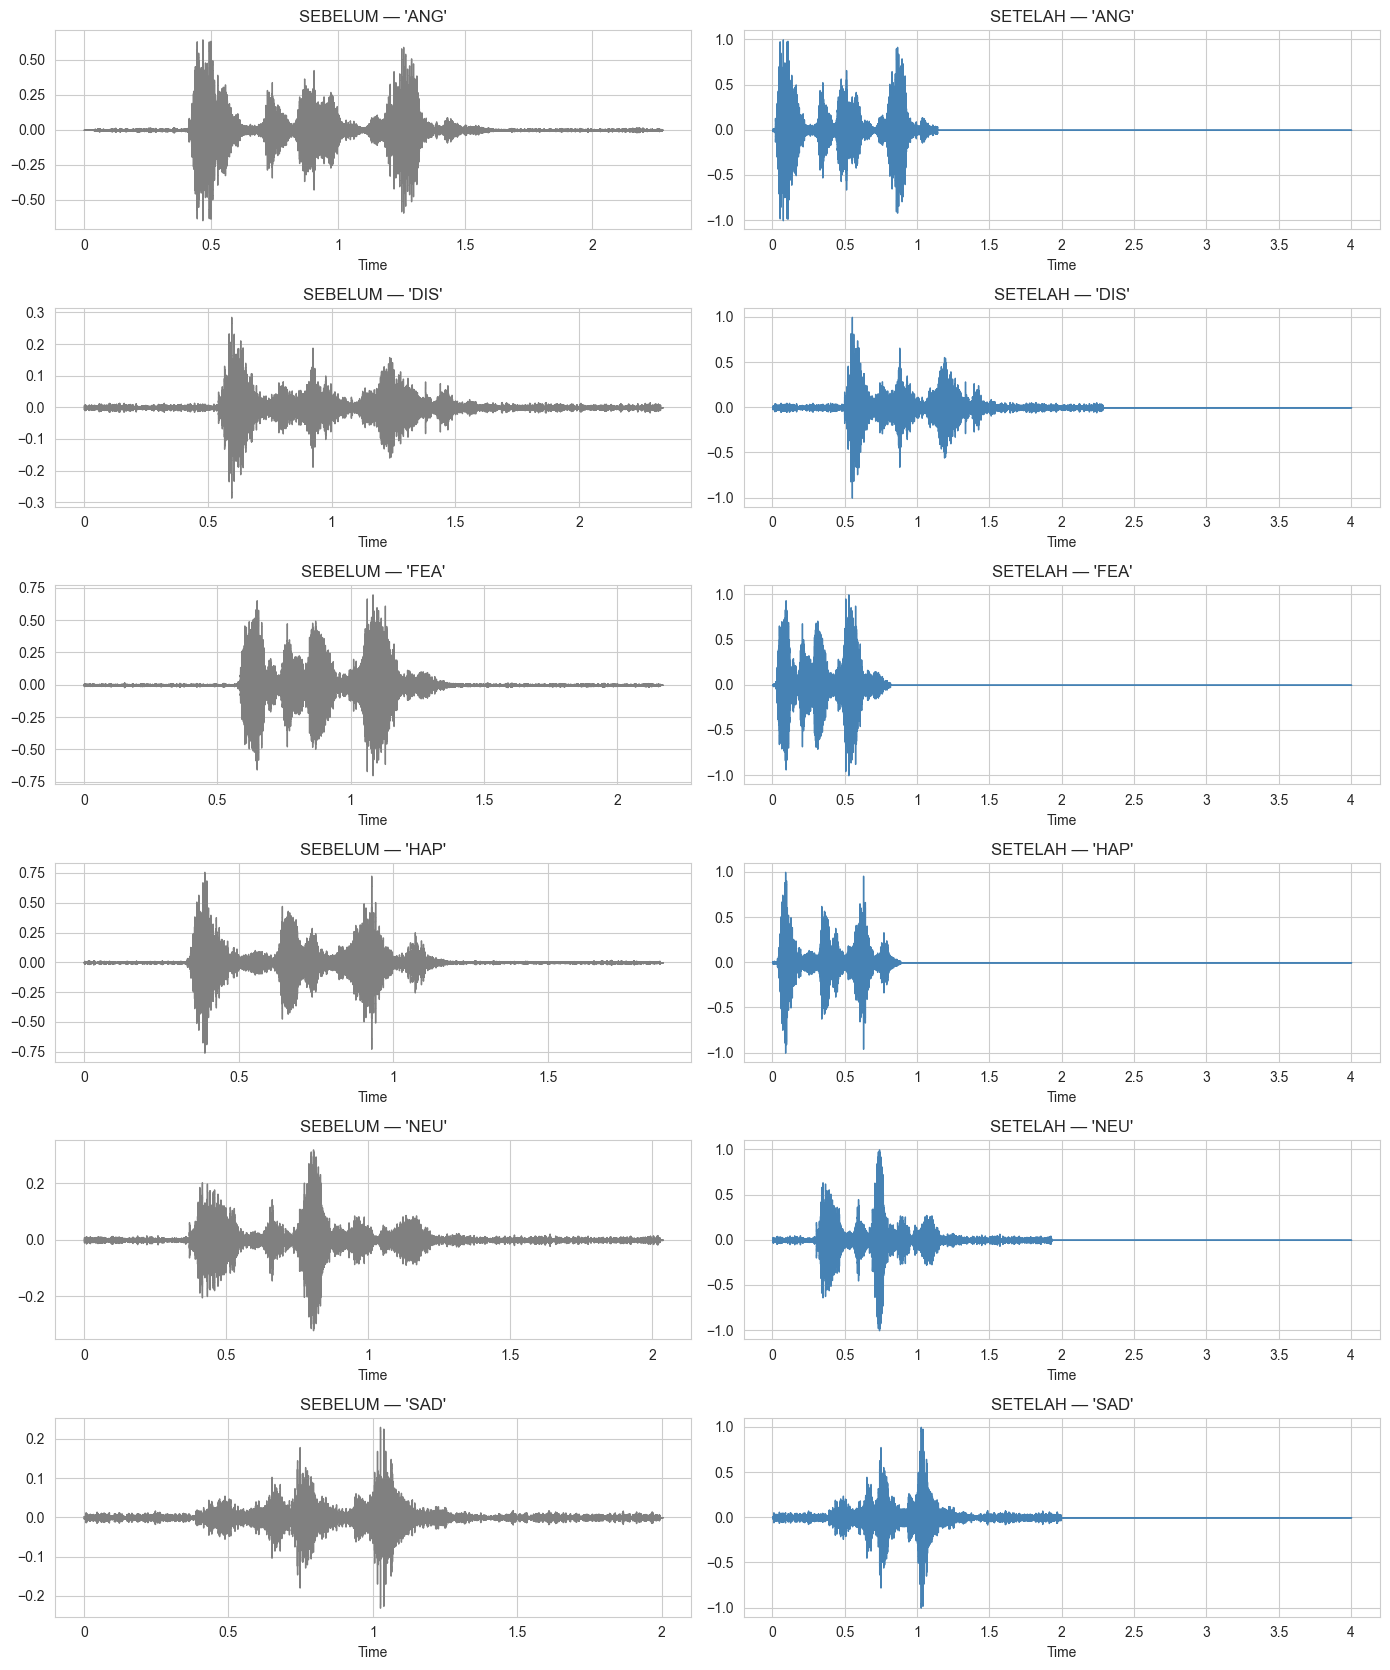


Visualisasi disimpan ke 'preprocessing_before_after_all_categories.png'


In [5]:
def visualize_preprocessing_effect_all_categories(split_name="train"):
    explain(
        "Perbandingan sinyal sebelum vs setelah preprocessing untuk SETIAP kategori",
        "Sinyal 'Sebelum' (abu-abu) biasanya punya jeda diam di awal/akhir dan "
        "amplitudo bervariasi antar aktor. Sinyal 'Setelah' (biru) sudah dipotong "
        "jeda diamnya, dinormalisasi ke rentang [-1, 1], dan disamakan durasinya "
        "menjadi tepat 4 detik (sisa setelah suara aktif akan berupa garis lurus "
        "nol = padding, bukan error)."
    )

    folder = os.path.join(BASE_DIR, split_name)
    label_folders = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])
    n_class = len(label_folders)

    fig, axes = plt.subplots(n_class, 2, figsize=(14, 2.8 * n_class))
    if n_class == 1:
        axes = axes.reshape(1, 2)

    for idx, label in enumerate(label_folders):
        files = glob.glob(os.path.join(folder, label, "*.wav"))
        if not files:
            continue
        sample_path = files[0]

        y_raw, sr_raw = librosa.load(sample_path, sr=SR)
        y_clean, sr_clean = load_and_preprocess_audio(sample_path)

        librosa.display.waveshow(y_raw, sr=sr_raw, ax=axes[idx, 0], color="gray")
        axes[idx, 0].set_title(f"SEBELUM — '{label}'")

        librosa.display.waveshow(y_clean, sr=sr_clean, ax=axes[idx, 1], color="steelblue")
        axes[idx, 1].set_title(f"SETELAH — '{label}'")

    plt.tight_layout()
    plt.savefig("preprocessing_before_after_all_categories.png", dpi=150)
    plt.show()
    print("\nVisualisasi disimpan ke 'preprocessing_before_after_all_categories.png'")

visualize_preprocessing_effect_all_categories("train")

## 3. Framing & Windowing (Demonstrasi Konsep dari Slide)

Sinyal audio bersifat **non-stasioner**
(frekuensinya berubah-ubah dari waktu ke waktu, misalnya saat seseorang
berbicara), sehingga dianalisis dengan **short-term analysis**: dipecah
menjadi frame-frame pendek yang diasumsikan stasioner di dalamnya, lalu
diberi **window function** (Hanning/Hamming) untuk menghindari diskontinuitas
tajam di tepi setiap frame yang bisa menimbulkan noise frekuensi tinggi palsu
saat ditransformasi ke domain frekuensi (efek **spectral leakage**).

**Catatan penting:** Pada notebook ini, proses framing+windowing TIDAK
ditulis manual dengan loop, karena seluruh fungsi `librosa.feature.*` yang
dipakai pada bagian Ekstraksi Fitur (RMS, ZCR, spectral centroid, MFCC, dst)
SUDAH melakukan framing dan windowing secara otomatis di belakang layar,
dengan window default **Hann** (mirip Hanning di slide) dan parameter
`frame_length`/`hop_length` yang kita kontrol lewat `FRAME_LENGTH`/`HOP_LENGTH`
pada konfigurasi di atas. Jadi tidak ada fitur yang hilang — hanya
implementasinya dibungkus oleh library, bukan ditulis ulang dari nol.

Sel berikut adalah demonstrasi VISUAL murni untuk membuktikan & memahami
konsep tersebut secara konkret (tidak dipakai untuk fitur final).


>> Demonstrasi efek Windowing pada satu frame
   Penjelasan: Tanpa windowing (rectangular), pemotongan frame menimbulkan diskontinuitas tajam di kedua ujung -> saat di-FFT, ini bocor menjadi energi di banyak frekuensi yang sebenarnya tidak ada pada sinyal asli (spectral leakage). Window Hann melembutkan tepi frame menuju nol, sehingga spektrum FFT yang dihasilkan lebih 'bersih' dan fokus pada frekuensi yang benar-benar ada.


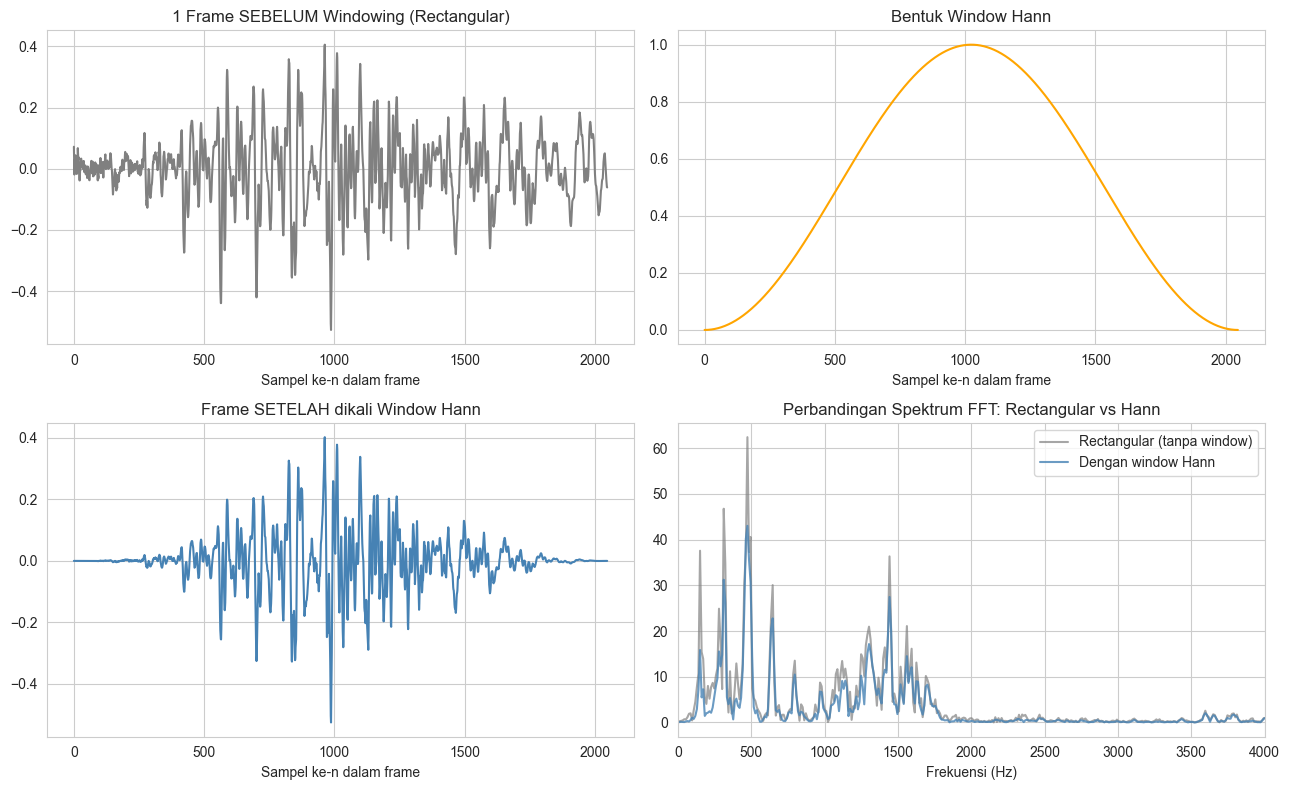


Visualisasi disimpan ke 'demo_framing_windowing.png'


In [6]:
# ======================================================================
# FUNGSI: demo_framing_windowing
# ----------------------------------------------------------------------
# Tujuan: Mengambil SATU frame contoh dari sinyal audio, lalu menunjukkan
# secara visual: (a) bentuk frame sebelum windowing (terpotong tajam di
# tepi -> diskontinuitas), (b) bentuk window Hann itu sendiri, (c) frame
# setelah dikali window (tepi jadi halus ke nol), dan (d) perbandingan
# spektrum FFT dari frame rectangular vs frame yang sudah di-window --
# untuk membuktikan klaim slide bahwa windowing mengurangi noise spektral.
# ======================================================================
def demo_framing_windowing(split_name="train"):
    explain(
        "Demonstrasi efek Windowing pada satu frame",
        "Tanpa windowing (rectangular), pemotongan frame menimbulkan "
        "diskontinuitas tajam di kedua ujung -> saat di-FFT, ini bocor "
        "menjadi energi di banyak frekuensi yang sebenarnya tidak ada "
        "pada sinyal asli (spectral leakage). Window Hann melembutkan "
        "tepi frame menuju nol, sehingga spektrum FFT yang dihasilkan "
        "lebih 'bersih' dan fokus pada frekuensi yang benar-benar ada."
    )

    folder = os.path.join(BASE_DIR, split_name)
    wav_files = glob.glob(os.path.join(folder, "*", "*.wav"))
    y, sr = load_and_preprocess_audio(wav_files[0])

    start = int(0.3 * sr)   # ambil 1 frame contoh dari posisi 0.3 detik (area suara aktif)
    frame_rect = y[start:start + FRAME_LENGTH]

    hann_window = np.hanning(FRAME_LENGTH)
    frame_windowed = frame_rect * hann_window

    fft_rect = np.abs(np.fft.rfft(frame_rect))
    fft_windowed = np.abs(np.fft.rfft(frame_windowed))
    freqs = np.fft.rfftfreq(FRAME_LENGTH, d=1/sr)

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))

    axes[0, 0].plot(frame_rect, color="gray")
    axes[0, 0].set_title("1 Frame SEBELUM Windowing (Rectangular)")
    axes[0, 0].set_xlabel("Sampel ke-n dalam frame")

    axes[0, 1].plot(hann_window, color="orange")
    axes[0, 1].set_title("Bentuk Window Hann")
    axes[0, 1].set_xlabel("Sampel ke-n dalam frame")

    axes[1, 0].plot(frame_windowed, color="steelblue")
    axes[1, 0].set_title("Frame SETELAH dikali Window Hann")
    axes[1, 0].set_xlabel("Sampel ke-n dalam frame")

    axes[1, 1].plot(freqs, fft_rect, label="Rectangular (tanpa window)", color="gray", alpha=0.7)
    axes[1, 1].plot(freqs, fft_windowed, label="Dengan window Hann", color="steelblue", alpha=0.8)
    axes[1, 1].set_title("Perbandingan Spektrum FFT: Rectangular vs Hann")
    axes[1, 1].set_xlabel("Frekuensi (Hz)")
    axes[1, 1].set_xlim(0, 4000)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig("demo_framing_windowing.png", dpi=150)
    plt.show()
    print("\nVisualisasi disimpan ke 'demo_framing_windowing.png'")

demo_framing_windowing("train")

## 4. Ekstraksi Fitur

Fungsi-fungsi berikut dijalankan pada sinyal audio yang SUDAH dipreprocessing.
Semua memanggil `librosa.feature.*` dengan `frame_length=FRAME_LENGTH,
hop_length=HOP_LENGTH` (kecuali fungsi yang memang tidak menerima parameter
itu, seperti MFCC yang memakai `n_fft`/`hop_length` setara) agar konsisten
dengan konfigurasi framing yang sudah ditetapkan di atas.

In [7]:
# ======================================================================
# FUNGSI: extract_label_from_filename
# ======================================================================
def extract_label_from_filename(filepath):
    return os.path.basename(os.path.dirname(filepath))

In [8]:
# ======================================================================
# FUNGSI: extract_time_domain_features
# ----------------------------------------------------------------------
# RMS Energy & Zero Crossing Rate, dihitung PER FRAME (frame_length=2048,
# hop_length=512 sesuai konfigurasi), lalu diringkas mean & std.
# ======================================================================
def extract_time_domain_features(y):
    rms = librosa.feature.rms(y=y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    return {
        "rms_mean": np.mean(rms), "rms_std": np.std(rms),
        "zcr_mean": np.mean(zcr), "zcr_std": np.std(zcr),
    }

In [9]:
# ======================================================================
# FUNGSI: extract_frequency_domain_features
# ----------------------------------------------------------------------
# Spectral Centroid, Bandwidth, Roll-off dari STFT (otomatis menggunakan
# window Hann & framing sesuai n_fft/hop_length).
# ======================================================================
def extract_frequency_domain_features(y, sr):
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    return {
        "centroid_mean": np.mean(centroid), "centroid_std": np.std(centroid),
        "bandwidth_mean": np.mean(bandwidth), "bandwidth_std": np.std(bandwidth),
        "rolloff_mean": np.mean(rolloff), "rolloff_std": np.std(rolloff),
    }

In [10]:
# ======================================================================
# FUNGSI: extract_mfcc_features
# ----------------------------------------------------------------------
# 13 koefisien MFCC + Delta + Delta-Delta, mean & std -> 78 fitur.
# Sesuai slide: MFCC = log-Mel energi per frame -> DCT -> koefisien cepstral.
# ======================================================================
def extract_mfcc_features(y, sr):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)
    delta_mfcc = librosa.feature.delta(mfcc, order=1)
    delta2_mfcc = librosa.feature.delta(mfcc, order=2)

    feats = {}
    for i in range(N_MFCC):
        feats[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        feats[f"mfcc_{i+1}_std"] = np.std(mfcc[i])
        feats[f"delta_mfcc_{i+1}_mean"] = np.mean(delta_mfcc[i])
        feats[f"delta_mfcc_{i+1}_std"] = np.std(delta_mfcc[i])
        feats[f"delta2_mfcc_{i+1}_mean"] = np.mean(delta2_mfcc[i])
        feats[f"delta2_mfcc_{i+1}_std"] = np.std(delta2_mfcc[i])
    return feats

In [11]:
# ======================================================================
# FUNGSI: extract_mel_spectrogram
# ----------------------------------------------------------------------
# Representasi 2D (waktu x frekuensi-mel) skala dB, untuk input CNN.
# ======================================================================
def extract_mel_spectrogram(y, sr):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < MAX_PAD_LEN:
        pad_width = MAX_PAD_LEN - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode="constant")
    else:
        mel_db = mel_db[:, :MAX_PAD_LEN]
    return mel_db

In [12]:
# ======================================================================
# FUNGSI: process_dataset
# ======================================================================
def process_dataset(split_name):
    folder = os.path.join(BASE_DIR, split_name)
    wav_files = glob.glob(os.path.join(folder, "*", "*.wav"))

    explain(
        f"Memproses folder '{split_name}'",
        f"Ditemukan {len(wav_files)} file audio yang akan dipreprocessing lalu "
        f"diekstrak fiturnya satu per satu."
    )

    rows, mel_list, labels = [], [], []

    for filepath in tqdm(wav_files, desc=f"Preprocessing + Ekstraksi fitur ({split_name})"):
        try:
            y, sr = load_and_preprocess_audio(filepath)
            label = extract_label_from_filename(filepath)

            feats = {"filename": os.path.basename(filepath), "label": label}
            feats.update(extract_time_domain_features(y))
            feats.update(extract_frequency_domain_features(y, sr))
            feats.update(extract_mfcc_features(y, sr))
            rows.append(feats)

            mel_list.append(extract_mel_spectrogram(y, sr))
            labels.append(label)
        except Exception as e:
            print(f"  -> Gagal memproses {filepath}: {e}")

    df_features = pd.DataFrame(rows)
    mel_array = np.array(mel_list)
    labels = np.array(labels)
    return df_features, mel_array, labels

In [13]:
# ======================================================================
# FUNGSI: print_summary
# ======================================================================
def print_summary(df, split_name):
    explain(
        f"Ringkasan data {split_name.upper()}",
        "Menampilkan total sampel yang berhasil diproses dan jumlah kolom "
        "fitur yang dihasilkan (di luar kolom filename & label)."
    )
    print(f"Jumlah sampel       : {df.shape[0]}")
    print(f"Jumlah fitur tabular: {df.shape[1] - 2}")

    explain(
        "Distribusi jumlah sampel per label emosi",
        "Penting untuk memeriksa apakah data SEIMBANG antar kelas emosi."
    )
    print(df["label"].value_counts())

    explain(
        "Contoh 5 baris data pertama",
        "Memastikan struktur tabel sudah sesuai harapan sebelum dipakai untuk training."
    )
    display(df.head())

### 4.1 Jalankan preprocessing + ekstraksi fitur untuk data TRAIN dan TEST

In [14]:
df_train, mel_train, labels_train = process_dataset("train")
print_summary(df_train, "train")

df_train.to_csv("features_train.csv", index=False)
np.save("melspec_train.npy", mel_train)
np.save("labels_train.npy", labels_train)

explain(
    "File hasil ekstraksi fitur TRAIN disimpan",
    "'features_train.csv' berisi fitur tabular (untuk SVM/RF), sedangkan "
    "'melspec_train.npy' berisi array Mel Spectrogram (untuk CNN)."
)
print(f"Shape Mel Spectrogram train: {mel_train.shape}")


>> Memproses folder 'train'
   Penjelasan: Ditemukan 5967 file audio yang akan dipreprocessing lalu diekstrak fiturnya satu per satu.


Preprocessing + Ekstraksi fitur (train): 100%|██████████| 5967/5967 [05:01<00:00, 19.79it/s]



>> Ringkasan data TRAIN
   Penjelasan: Menampilkan total sampel yang berhasil diproses dan jumlah kolom fitur yang dihasilkan (di luar kolom filename & label).
Jumlah sampel       : 5967
Jumlah fitur tabular: 88

>> Distribusi jumlah sampel per label emosi
   Penjelasan: Penting untuk memeriksa apakah data SEIMBANG antar kelas emosi.
label
ANG    1019
DIS    1019
FEA    1019
HAP    1019
SAD    1019
NEU     872
Name: count, dtype: int64

>> Contoh 5 baris data pertama
   Penjelasan: Memastikan struktur tabel sudah sesuai harapan sebelum dipakai untuk training.


,filename,label,rms_mean,rms_std,zcr_mean,zcr_std,centroid_mean,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,mfcc_1_mean,mfcc_1_std,delta_mfcc_1_mean,delta_mfcc_1_std,delta2_mfcc_1_mean,delta2_mfcc_1_std,mfcc_2_mean,mfcc_2_std,delta_mfcc_2_mean,delta_mfcc_2_std,delta2_mfcc_2_mean,delta2_mfcc_2_std,mfcc_3_mean,mfcc_3_std,delta_mfcc_3_mean,delta_mfcc_3_std,delta2_mfcc_3_mean,delta2_mfcc_3_std,mfcc_4_mean,mfcc_4_std,delta_mfcc_4_mean,delta_mfcc_4_std,delta2_mfcc_4_mean,delta2_mfcc_4_std,mfcc_5_mean,mfcc_5_std,delta_mfcc_5_mean,delta_mfcc_5_std,delta2_mfcc_5_mean,delta2_mfcc_5_std,mfcc_6_mean,mfcc_6_std,delta_mfcc_6_mean,delta_mfcc_6_std,delta2_mfcc_6_mean,delta2_mfcc_6_std,mfcc_7_mean,mfcc_7_std,delta_mfcc_7_mean,delta_mfcc_7_std,delta2_mfcc_7_mean,delta2_mfcc_7_std,mfcc_8_mean,mfcc_8_std,delta_mfcc_8_mean,delta_mfcc_8_std,delta2_mfcc_8_mean,delta2_mfcc_8_std,mfcc_9_mean,mfcc_9_std,delta_mfcc_9_mean,delta_mfcc_9_std,delta2_mfcc_9_mean,delta2_mfcc_9_std,mfcc_10_mean,mfcc_10_std,delta_mfcc_10_mean,delta_mfcc_10_std,delta2_mfcc_10_mean,delta2_mfcc_10_std,mfcc_11_mean,mfcc_11_std,delta_mfcc_11_mean,delta_mfcc_11_std,delta2_mfcc_11_mean,delta2_mfcc_11_std,mfcc_12_mean,mfcc_12_std,delta_mfcc_12_mean,delta_mfcc_12_std,delta2_mfcc_12_mean,delta2_mfcc_12_std,mfcc_13_mean,mfcc_13_std,delta_mfcc_13_mean,delta_mfcc_13_std,delta2_mfcc_13_mean,delta2_mfcc_13_std
0,1001_DFA_ANG_XX.wav,ANG,0.034000,0.067255,0.030827,0.053701,546.051894,918.466154,493.866452,788.657079,1034.091628,1767.620483,-459.207855,188.609589,-2.977757,12.744233,-0.505950,6.759535,38.407104,62.157951,-0.643877,4.992132,-0.187290,2.989186,-14.409048,28.818645,0.636779,4.511295,0.138425,2.434912,14.464017,25.721178,-0.368435,3.003481,0.102583,1.822645,-5.673689,14.785378,0.162315,2.117896,0.155127,1.645881,3.705936,11.472752,-0.166435,2.630777,0.082188,1.175539,-10.799590,18.352026,0.163648,2.076411,0.028006,1.109919,-2.367100,9.769007,0.027308,1.819128,-0.096602,1.349059,-6.769876,12.487352,0.234065,1.157457,0.007788,0.821266,0.194915,4.323374,-0.010223,0.734742,0.002001,0.525314,-4.628935,8.043367,0.074710,0.900623,-0.046374,0.614184,0.061565,3.404992,-0.030673,0.512007,-0.011645,0.440471,-0.232723,5.542812,-0.063645,1.152898,-0.049284,0.870541
1,1001_IEO_ANG_HI.wav,ANG,0.026059,0.051225,0.036045,0.063238,588.553452,966.193679,526.362709,818.630554,1137.587919,1870.765266,-453.609924,170.543655,-1.370067,10.557590,-0.086628,5.649292,39.633125,62.540230,-0.469068,4.457332,0.164690,2.445938,-11.705235,24.181622,0.052340,3.293770,-0.105746,2.223753,9.317976,19.718687,-0.486381,2.480912,-0.041133,1.413581,-12.717559,28.173204,-0.296324,4.598656,0.035437,1.424874,2.116374,11.285510,-0.130762,2.490004,-0.174380,1.773669,-5.026265,14.480159,0.253239,2.780011,0.090962,1.358397,-1.784658,7.978985,0.116039,1.651127,-0.062427,1.020377,-5.637047,13.077530,0.029596,1.482554,0.013702,0.876346,-0.805183,4.653501,0.093479,0.904876,-0.024896,0.617632,-4.749922,9.769512,0.230987,1.543131,-0.015602,0.842202,2.591325,5.648476,-0.015390,0.830921,0.023593,0.473971,-1.817947,5.106125,0.096151,1.001653,0.012686,0.670610
2,1001_IEO_ANG_LO.wav,ANG,0.033832,0.065967,0.029957,0.037574,679.346674,725.670962,861.102047,851.873637,1433.140467,1536.901114,-408.320007,168.624130,-1.249224,10.060075,-0.018867,4.000176,70.994278,71.079422,-0.691903,4.706624,-0.002565,2.346329,-3.463410,23.604740,-0.092992,2.796914,-0.026088,1.485776,20.995081,22.313274,-0.257143,2.093473,-0.024516,1.099112,-2.593110,22.754023,-0.132546,3.972345,-0.005970,1.554809,9.312846,12.445954,-0.144759,2.038938,0.001818,1.117296,-5.806697,9.417646,0.061037,1.851909,0.023443,1.007607,1.532013,5.589193,-0.026653,1.067730,-0.005237,0.729063,-4.379853,10.797230,-0.032298,1.519160,0.020463,0.837813,-1.207820,5.143443,0.007013,0.945048,0.015064,0.495920,-5.368981,6.324126,0.055891,0.637387,-0.009368,0.540582,-0.445772,6.959759,0.011511,0.900627,0.011481,0.441375,-0.915299,4.982213,-0.012767,1.170957,0.012851,0.814592
3,


>> File hasil ekstraksi fitur TRAIN disimpan
   Penjelasan: 'features_train.csv' berisi fitur tabular (untuk SVM/RF), sedangkan 'melspec_train.npy' berisi array Mel Spectrogram (untuk CNN).
Shape Mel Spectrogram train: (5967, 128, 174)


In [15]:
df_test, mel_test, labels_test = process_dataset("test")
print_summary(df_test, "test")

df_test.to_csv("features_test.csv", index=False)
np.save("melspec_test.npy", mel_test)
np.save("labels_test.npy", labels_test)

explain(
    "File hasil ekstraksi fitur TEST disimpan",
    "Sama seperti data train, file CSV untuk fitur tabular dan .npy untuk "
    "mel spectrogram yang akan dipakai saat evaluasi model."
)
print(f"Shape Mel Spectrogram test: {mel_test.shape}")


>> Memproses folder 'test'
   Penjelasan: Ditemukan 1475 file audio yang akan dipreprocessing lalu diekstrak fiturnya satu per satu.


Preprocessing + Ekstraksi fitur (test): 100%|██████████| 1475/1475 [01:08<00:00, 21.67it/s]



>> Ringkasan data TEST
   Penjelasan: Menampilkan total sampel yang berhasil diproses dan jumlah kolom fitur yang dihasilkan (di luar kolom filename & label).
Jumlah sampel       : 1475
Jumlah fitur tabular: 88

>> Distribusi jumlah sampel per label emosi
   Penjelasan: Penting untuk memeriksa apakah data SEIMBANG antar kelas emosi.
label
ANG    252
DIS    252
FEA    252
HAP    252
SAD    252
NEU    215
Name: count, dtype: int64

>> Contoh 5 baris data pertama
   Penjelasan: Memastikan struktur tabel sudah sesuai harapan sebelum dipakai untuk training.


,filename,label,rms_mean,rms_std,zcr_mean,zcr_std,centroid_mean,centroid_std,bandwidth_mean,bandwidth_std,rolloff_mean,rolloff_std,mfcc_1_mean,mfcc_1_std,delta_mfcc_1_mean,delta_mfcc_1_std,delta2_mfcc_1_mean,delta2_mfcc_1_std,mfcc_2_mean,mfcc_2_std,delta_mfcc_2_mean,delta_mfcc_2_std,delta2_mfcc_2_mean,delta2_mfcc_2_std,mfcc_3_mean,mfcc_3_std,delta_mfcc_3_mean,delta_mfcc_3_std,delta2_mfcc_3_mean,delta2_mfcc_3_std,mfcc_4_mean,mfcc_4_std,delta_mfcc_4_mean,delta_mfcc_4_std,delta2_mfcc_4_mean,delta2_mfcc_4_std,mfcc_5_mean,mfcc_5_std,delta_mfcc_5_mean,delta_mfcc_5_std,delta2_mfcc_5_mean,delta2_mfcc_5_std,mfcc_6_mean,mfcc_6_std,delta_mfcc_6_mean,delta_mfcc_6_std,delta2_mfcc_6_mean,delta2_mfcc_6_std,mfcc_7_mean,mfcc_7_std,delta_mfcc_7_mean,delta_mfcc_7_std,delta2_mfcc_7_mean,delta2_mfcc_7_std,mfcc_8_mean,mfcc_8_std,delta_mfcc_8_mean,delta_mfcc_8_std,delta2_mfcc_8_mean,delta2_mfcc_8_std,mfcc_9_mean,mfcc_9_std,delta_mfcc_9_mean,delta_mfcc_9_std,delta2_mfcc_9_mean,delta2_mfcc_9_std,mfcc_10_mean,mfcc_10_std,delta_mfcc_10_mean,delta_mfcc_10_std,delta2_mfcc_10_mean,delta2_mfcc_10_std,mfcc_11_mean,mfcc_11_std,delta_mfcc_11_mean,delta_mfcc_11_std,delta2_mfcc_11_mean,delta2_mfcc_11_std,mfcc_12_mean,mfcc_12_std,delta_mfcc_12_mean,delta_mfcc_12_std,delta2_mfcc_12_mean,delta2_mfcc_12_std,mfcc_13_mean,mfcc_13_std,delta_mfcc_13_mean,delta_mfcc_13_std,delta2_mfcc_13_mean,delta2_mfcc_13_std
0,1074_DFA_ANG_XX.wav,ANG,0.043119,0.077461,0.038379,0.060735,691.143170,1003.181747,581.798131,794.023863,1288.320341,1848.053962,-418.645081,173.949066,-1.107914,15.896210,-0.642159,7.804097,43.381439,59.175785,-0.421151,4.673100,0.037664,2.709131,-16.255659,40.773708,-0.293444,8.754891,0.278684,3.969626,20.592878,31.023422,-0.397138,3.390520,-0.021719,1.725444,-11.258669,21.409018,-0.090159,3.672092,0.089510,1.711701,-3.514981,15.036553,-0.176464,3.224026,-0.012226,1.966294,-5.721029,16.249271,0.231979,2.914429,0.132576,1.631528,-1.119580,8.806878,-0.045514,1.574121,0.017127,0.972843,-3.631528,9.591063,0.039945,1.715286,0.066684,0.846077,-3.037321,6.466989,-0.094301,1.119053,-0.029645,0.701448,-1.339967,5.302869,0.009670,0.886969,-0.032758,0.469078,-0.189032,6.557244,0.057800,1.094820,-0.022370,0.619518,0.772887,4.302762,-0.016959,0.673181,-0.007002,0.603991
1,1074_IEO_ANG_HI.wav,ANG,0.073073,0.119328,0.042226,0.061405,773.548276,1081.475046,585.339233,820.383859,1436.874548,2017.376415,-383.408539,196.108063,-1.793849,12.604104,-0.814646,7.393085,35.142910,50.281666,-0.220154,4.738212,0.006199,2.251304,-27.857805,45.298634,0.406744,5.811476,0.287076,3.665322,13.289518,24.514999,-0.562052,1.924056,-0.100642,1.231740,-19.470226,30.192797,0.313536,2.902496,0.185323,1.912319,2.709634,11.760159,0.149522,2.192651,0.046235,1.277438,-6.113101,15.932420,-0.068959,2.416865,0.116878,0.894549,-0.976735,7.717776,-0.069567,1.615752,0.004843,0.872916,-5.403224,9.542186,-0.049086,1.326712,0.015329,0.633870,1.064160,4.373062,-0.028886,0.715962,0.004340,0.535971,-3.243993,6.058613,-0.052120,0.927384,0.005763,0.446391,-6.911063,10.950438,-0.065799,1.153243,-0.012499,0.552640,-1.024001,4.595809,0.093572,0.688096,-0.010295,0.518953
2,1074_IEO_ANG_LO.wav,ANG,0.046306,0.082333,0.023387,0.036966,512.197996,727.309489,595.194543,813.803685,1041.373086,1557.326527,-392.151855,149.521027,-1.969060,7.296093,-0.256499,4.012547,49.890858,66.873436,-0.642238,3.728352,-0.105310,1.705888,-1.912528,20.756706,0.166853,3.981236,0.082528,2.231260,14.023381,24.324205,-0.675223,2.364517,-0.008574,1.044746,-7.854570,15.683022,0.115461,2.007394,0.024605,0.847328,6.147924,11.291596,0.154103,2.028947,0.042788,0.955055,-2.931116,11.930155,0.090747,1.893334,0.026703,0.788394,-2.501444,9.407053,0.024548,1.629951,0.008786,0.971999,-4.354138,8.093170,0.091501,0.915696,0.000962,0.592286,1.221703,9.670737,0.247343,1.569792,0.036904,0.921881,1.388066,4.817618,-0.072378,0.903604,0.040931,0.488345,-4.078565,7.703262,-0.056472,1.088643,0.028252,0.612843,0.343245,5.711331,0.019959,1.144722,-0.014025,0.611383
3,107


>> File hasil ekstraksi fitur TEST disimpan
   Penjelasan: Sama seperti data train, file CSV untuk fitur tabular dan .npy untuk mel spectrogram yang akan dipakai saat evaluasi model.
Shape Mel Spectrogram test: (1475, 128, 174)


### 4.2 Visualisasi Fitur Domain Waktu & Domain Frekuensi — SEMUA Kategori


>> Boxplot seluruh fitur domain waktu & frekuensi per kategori emosi
   Penjelasan: Menampilkan distribusi RMS Energy, Zero Crossing Rate (domain waktu), serta Spectral Centroid, Bandwidth, Roll-off (domain frekuensi) untuk SETIAP kelas emosi, agar terlihat fitur mana yang paling membedakan.


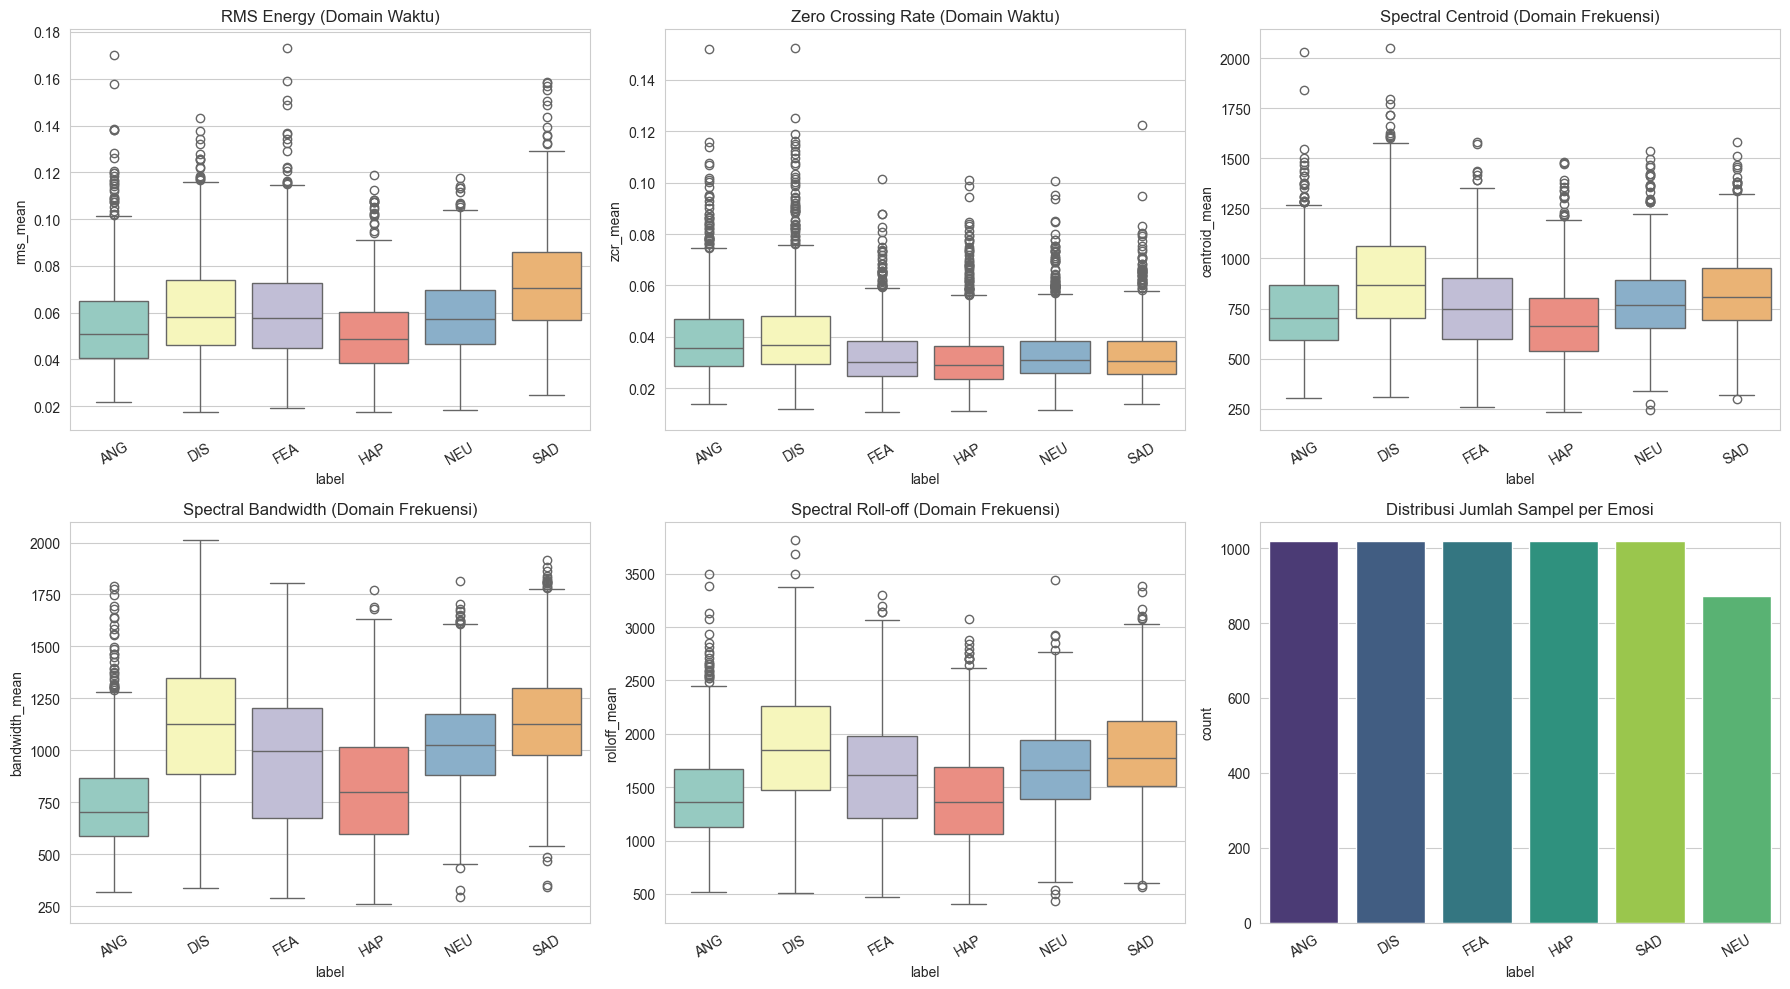


Visualisasi disimpan ke 'visualisasi_fitur_dasar_train.png'


In [16]:
def visualize_all_basic_features(df, split_name):
    explain(
        "Boxplot seluruh fitur domain waktu & frekuensi per kategori emosi",
        "Menampilkan distribusi RMS Energy, Zero Crossing Rate (domain waktu), "
        "serta Spectral Centroid, Bandwidth, Roll-off (domain frekuensi) untuk "
        "SETIAP kelas emosi, agar terlihat fitur mana yang paling membedakan."
    )

    fitur_dasar = ["rms_mean", "zcr_mean", "centroid_mean", "bandwidth_mean", "rolloff_mean"]
    judul = ["RMS Energy (Domain Waktu)", "Zero Crossing Rate (Domain Waktu)",
             "Spectral Centroid (Domain Frekuensi)", "Spectral Bandwidth (Domain Frekuensi)",
             "Spectral Roll-off (Domain Frekuensi)"]

    n = len(fitur_dasar)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, (kolom, title) in enumerate(zip(fitur_dasar, judul)):
        sns.boxplot(data=df, x="label", y=kolom, hue="label", legend=False, ax=axes[i], palette="Set3")
        axes[i].set_title(title)
        axes[i].tick_params(axis="x", rotation=30)

    sns.countplot(data=df, x="label", hue="label", legend=False,
                  order=df["label"].value_counts().index,
                  ax=axes[n], palette="viridis")
    axes[n].set_title("Distribusi Jumlah Sampel per Emosi")
    axes[n].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.savefig(f"visualisasi_fitur_dasar_{split_name}.png", dpi=150)
    plt.show()
    print(f"\nVisualisasi disimpan ke 'visualisasi_fitur_dasar_{split_name}.png'")

visualize_all_basic_features(df_train, "train")

### 4.3 Visualisasi Domain Waktu-Frekuensi (MFCC) — SEMUA Kategori


>> Heatmap rata-rata 13 koefisien MFCC per kategori emosi
   Penjelasan: Tiap baris = satu kelas emosi, tiap kolom = satu koefisien MFCC. Pola warna yang berbeda antar baris menunjukkan MFCC memang berbeda antar emosi -> alasan MFCC sangat berguna untuk klasifikasi emosi.


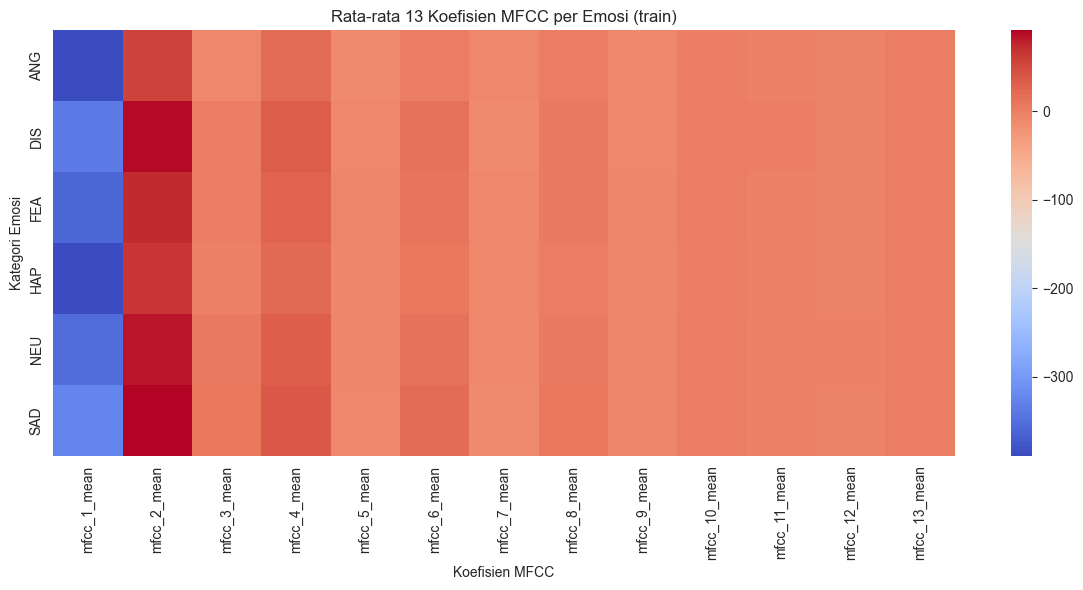


Visualisasi disimpan ke 'heatmap_mfcc_train.png'

>> Bar chart MFCC koefisien 1-5 dibandingkan langsung antar kategori
   Penjelasan: Memvisualisasikan nilai mean koefisien MFCC pertama (paling berpengaruh secara energi) berdampingan untuk semua kategori, melengkapi heatmap di atas dengan tampilan yang lebih mudah dibandingkan langsung.


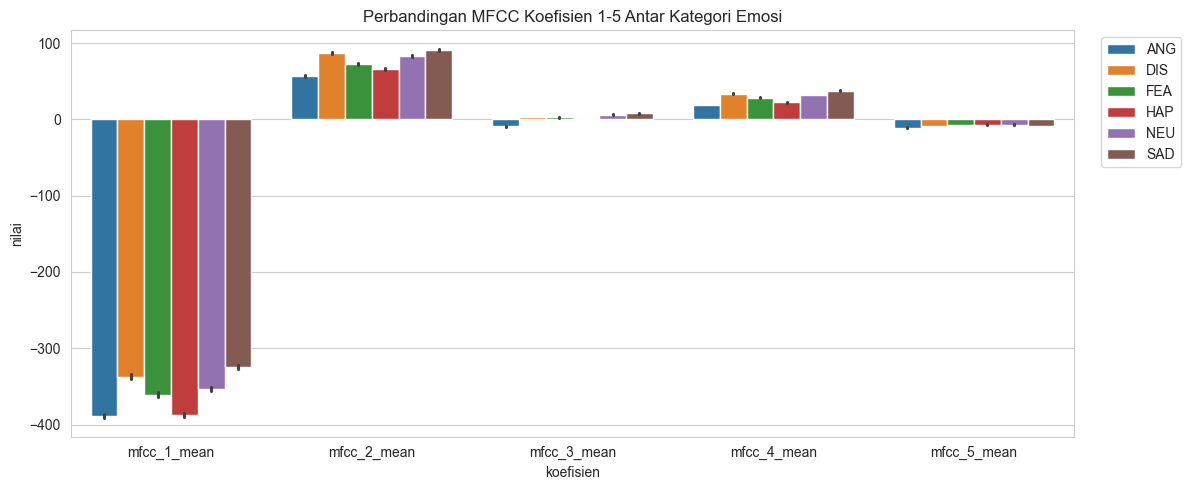


Visualisasi disimpan ke 'mfcc_per_kategori_train.png'


In [17]:
def visualize_mfcc_heatmap(df, split_name):
    explain(
        "Heatmap rata-rata 13 koefisien MFCC per kategori emosi",
        "Tiap baris = satu kelas emosi, tiap kolom = satu koefisien MFCC. "
        "Pola warna yang berbeda antar baris menunjukkan MFCC memang berbeda "
        "antar emosi -> alasan MFCC sangat berguna untuk klasifikasi emosi."
    )
    mfcc_cols = [c for c in df.columns if c.startswith("mfcc_") and c.endswith("_mean")]
    mfcc_means = df.groupby("label")[mfcc_cols].mean()

    plt.figure(figsize=(12, 6))
    sns.heatmap(mfcc_means, cmap="coolwarm", annot=False)
    plt.title(f"Rata-rata 13 Koefisien MFCC per Emosi ({split_name})")
    plt.xlabel("Koefisien MFCC")
    plt.ylabel("Kategori Emosi")
    plt.tight_layout()
    plt.savefig(f"heatmap_mfcc_{split_name}.png", dpi=150)
    plt.show()
    print(f"\nVisualisasi disimpan ke 'heatmap_mfcc_{split_name}.png'")


def visualize_mfcc_per_category(df, split_name, n_coef_show=5):
    explain(
        "Bar chart MFCC koefisien 1-5 dibandingkan langsung antar kategori",
        "Memvisualisasikan nilai mean koefisien MFCC pertama (paling berpengaruh "
        "secara energi) berdampingan untuk semua kategori, melengkapi heatmap "
        "di atas dengan tampilan yang lebih mudah dibandingkan langsung."
    )
    mfcc_cols = [f"mfcc_{i+1}_mean" for i in range(n_coef_show)]
    df_long = df.melt(id_vars="label", value_vars=mfcc_cols,
                       var_name="koefisien", value_name="nilai")

    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_long, x="koefisien", y="nilai", hue="label", palette="tab10")
    plt.title(f"Perbandingan MFCC Koefisien 1-{n_coef_show} Antar Kategori Emosi")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"mfcc_per_kategori_{split_name}.png", dpi=150)
    plt.show()
    print(f"\nVisualisasi disimpan ke 'mfcc_per_kategori_{split_name}.png'")

visualize_mfcc_heatmap(df_train, "train")
visualize_mfcc_per_category(df_train, "train")

### 4.4 Visualisasi Waveform & Mel Spectrogram — SEMUA Kategori (untuk CNN)


>> Waveform & Mel Spectrogram untuk SETIAP kategori emosi
   Penjelasan: Mengambil 1 contoh file dari MASING-MASING kelas emosi, agar terlihat perbedaan visual bentuk gelombang dan pola spektral antar emosi -- inilah representasi 2D yang akan 'dilihat' langsung oleh CNN.


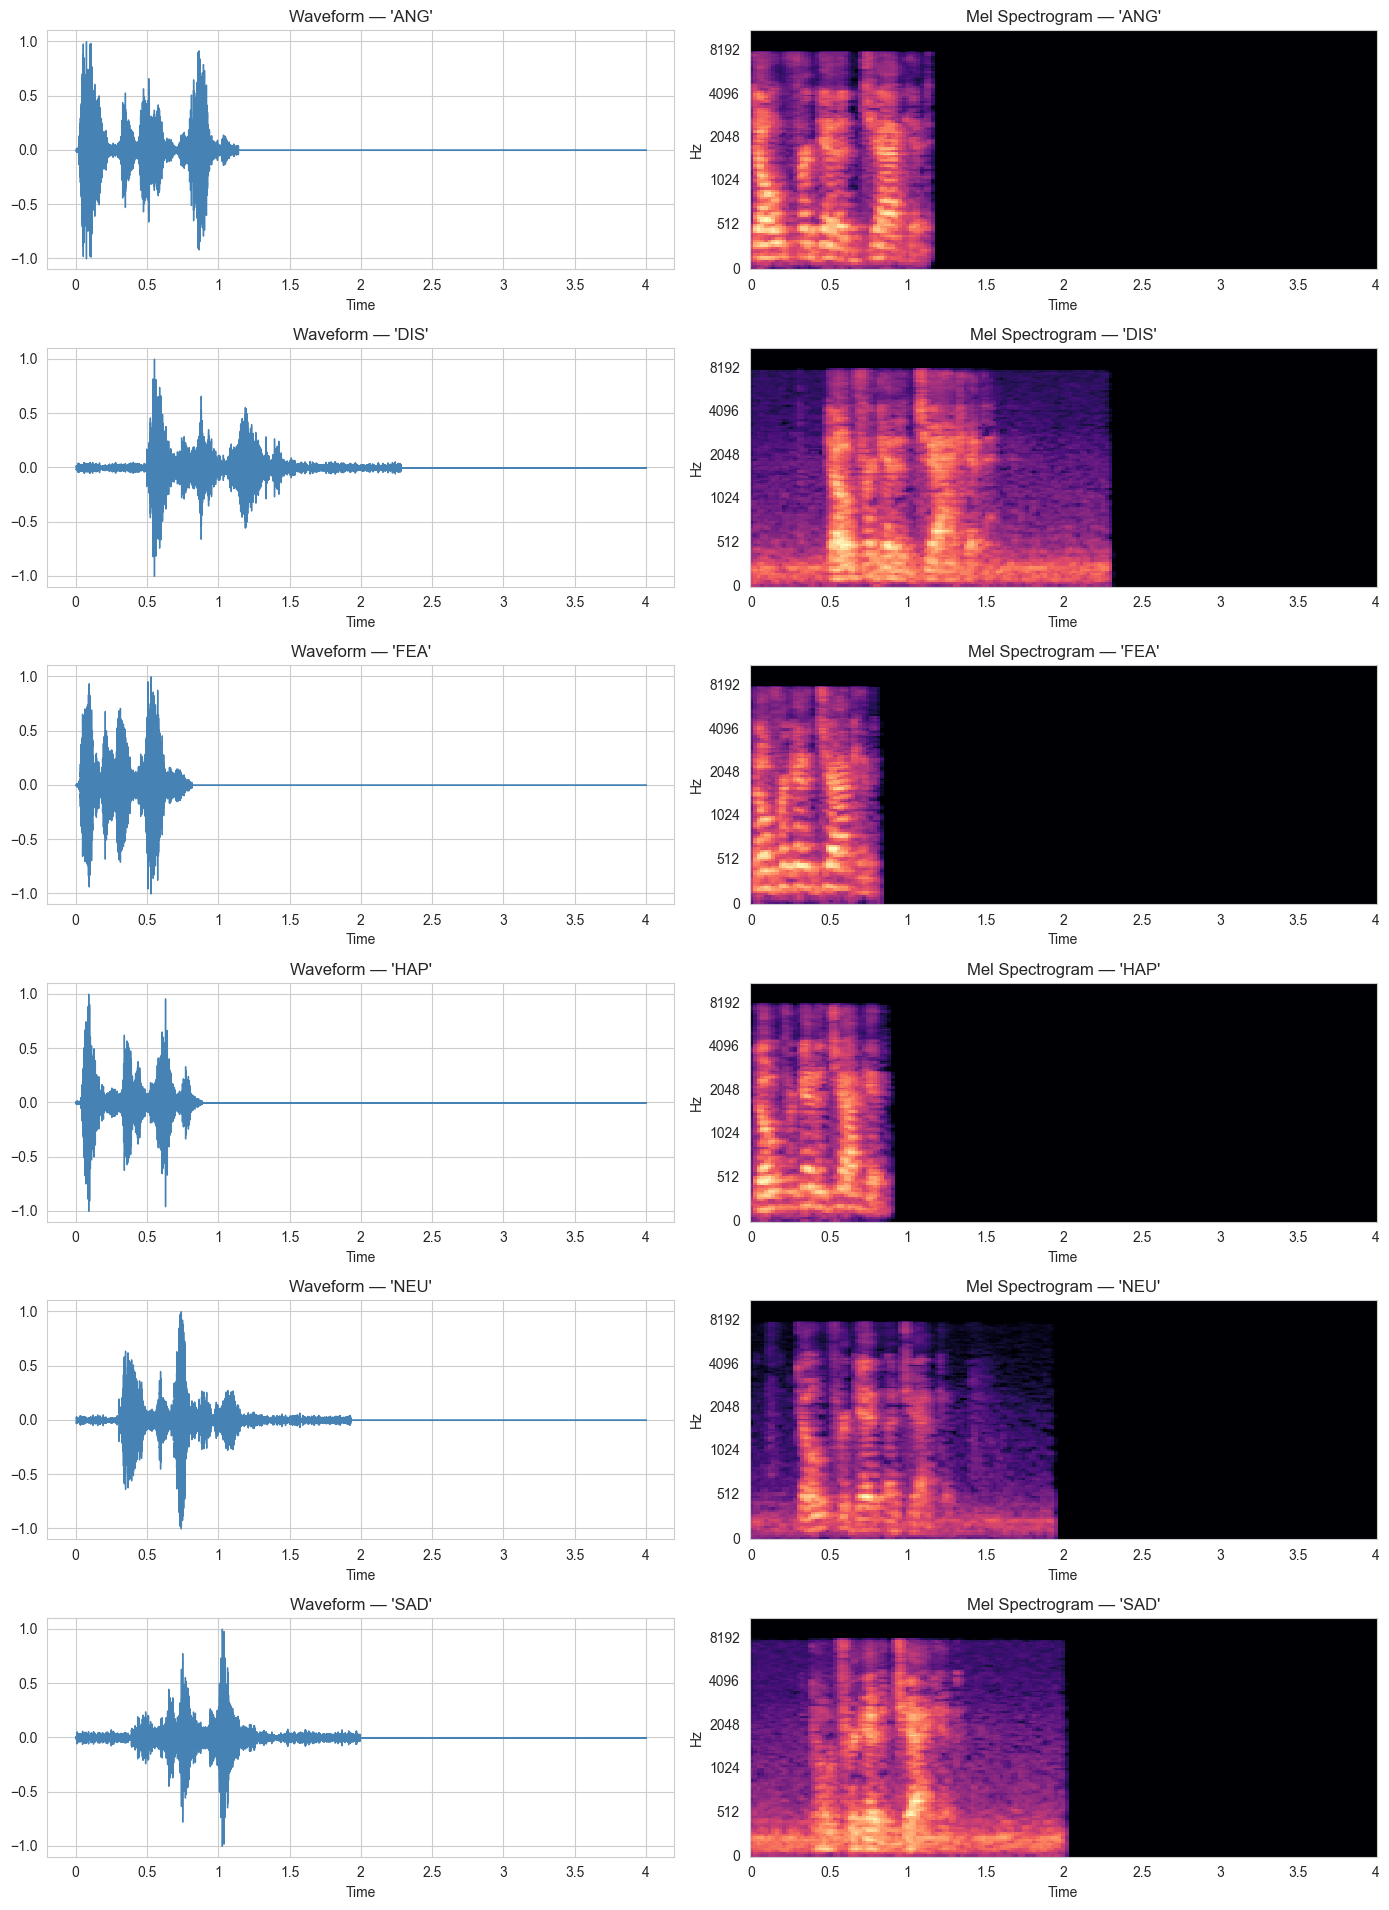


Visualisasi disimpan ke 'visualisasi_semua_kategori_audio.png'


In [18]:
def visualize_all_categories_audio(split_name="train"):
    explain(
        "Waveform & Mel Spectrogram untuk SETIAP kategori emosi",
        "Mengambil 1 contoh file dari MASING-MASING kelas emosi, agar terlihat "
        "perbedaan visual bentuk gelombang dan pola spektral antar emosi -- "
        "inilah representasi 2D yang akan 'dilihat' langsung oleh CNN."
    )

    folder = os.path.join(BASE_DIR, split_name)
    label_folders = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])

    n_class = len(label_folders)
    fig, axes = plt.subplots(n_class, 2, figsize=(14, 3.2 * n_class))
    if n_class == 1:
        axes = axes.reshape(1, 2)

    for idx, label in enumerate(label_folders):
        files = glob.glob(os.path.join(folder, label, "*.wav"))
        if not files:
            continue
        sample_path = files[0]
        y, sr = load_and_preprocess_audio(sample_path)

        librosa.display.waveshow(y, sr=sr, ax=axes[idx, 0], color="steelblue")
        axes[idx, 0].set_title(f"Waveform — '{label}'")

        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[idx, 1])
        axes[idx, 1].set_title(f"Mel Spectrogram — '{label}'")

    plt.tight_layout()
    plt.savefig("visualisasi_semua_kategori_audio.png", dpi=150)
    plt.show()
    print("\nVisualisasi disimpan ke 'visualisasi_semua_kategori_audio.png'")

visualize_all_categories_audio("train")

## 5. Training & Evaluasi Model

### 5.1 Muat fitur & tentukan kolom per skenario
- **A. Domain waktu saja** (RMS + ZCR)
- **B. MFCC saja** (MFCC + Delta + Delta-Delta)
- **C. Kombinasi semua fitur** (waktu + frekuensi + MFCC)

In [19]:
def load_tabular_features(path_train, path_test):
    df_train = pd.read_csv(path_train)
    df_test = pd.read_csv(path_test)

    time_cols = [c for c in df_train.columns if c.startswith(("rms_", "zcr_"))]
    freq_cols = [c for c in df_train.columns if c.startswith(("centroid_", "bandwidth_", "rolloff_"))]
    mfcc_cols = [c for c in df_train.columns if "mfcc" in c]

    explain(
        "Jumlah fitur pada masing-masing kelompok skenario",
        "Domain waktu (A) paling sederhana, MFCC (B) paling banyak (13 koefisien "
        "x mean/std x 3 varian), Kombinasi (C) menggabungkan semuanya."
    )
    print("Jumlah fitur domain waktu    :", len(time_cols))
    print("Jumlah fitur domain frekuensi:", len(freq_cols))
    print("Jumlah fitur MFCC (+delta)   :", len(mfcc_cols))
    return df_train, df_test, time_cols, freq_cols, mfcc_cols

df_train, df_test, time_cols, freq_cols, mfcc_cols = load_tabular_features(
    "features_train.csv", "features_test.csv"
)


>> Jumlah fitur pada masing-masing kelompok skenario
   Penjelasan: Domain waktu (A) paling sederhana, MFCC (B) paling banyak (13 koefisien x mean/std x 3 varian), Kombinasi (C) menggabungkan semuanya.
Jumlah fitur domain waktu    : 4
Jumlah fitur domain frekuensi: 6
Jumlah fitur MFCC (+delta)   : 78


### 5.2 Fungsi-fungsi training, evaluasi, dan visualisasi

In [20]:
def prepare_scenario_data(df_train, df_test, feature_cols, label_encoder=None):
    X_train = df_train[feature_cols].values
    X_test = df_test[feature_cols].values
    y_train_raw = df_train["label"].values
    y_test_raw = df_test["label"].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    if label_encoder is None:
        label_encoder = LabelEncoder()
        label_encoder.fit(y_train_raw)

    y_train = label_encoder.transform(y_train_raw)
    y_test = label_encoder.transform(y_test_raw)
    return X_train_scaled, X_test_scaled, y_train, y_test, label_encoder, scaler

In [21]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, label_encoder, model_name, scenario_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
    report = classification_report(y_test, y_pred, target_names=label_encoder.classes_)
    cm = confusion_matrix(y_test, y_pred)

    explain(
        f"Hasil evaluasi {model_name} pada skenario '{scenario_name}'",
        "Accuracy = persentase prediksi benar keseluruhan. Precision = dari semua "
        "prediksi suatu kelas, berapa persen benar. Recall = dari semua data "
        "aktual suatu kelas, berapa persen terdeteksi. F1 = rata-rata harmonik "
        "precision & recall, lebih adil saat data antar kelas tidak seimbang."
    )
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall    (macro): {recall:.4f}")
    print(f"F1-score  (macro): {f1:.4f}")

    explain(
        "Classification report per kelas",
        "Precision/recall/F1 untuk SETIAP kelas emosi secara terpisah, agar "
        "terlihat kelas mana yang paling sulit dikenali model."
    )
    print(report)

    return {
        "model": model_name, "scenario": scenario_name,
        "accuracy": acc, "precision": precision, "recall": recall, "f1": f1,
        "confusion_matrix": cm, "labels": label_encoder.classes_,
        "trained_model": model,
    }

In [22]:
def plot_confusion_matrix(result, filename_suffix=""):
    explain(
        f"Confusion Matrix — {result['model']} ({result['scenario']})",
        "Baris = label aktual, kolom = label prediksi. Nilai di luar diagonal "
        "menunjukkan jenis kesalahan; nilai di diagonal adalah prediksi benar."
    )
    cm = result["confusion_matrix"]
    labels = result["labels"]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix: {result['model']} ({result['scenario']})")
    plt.xlabel("Prediksi")
    plt.ylabel("Aktual")
    plt.tight_layout()
    fname = f"confmat_{result['model']}_{result['scenario']}{filename_suffix}.png".replace(" ", "_")
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"Confusion matrix disimpan ke '{fname}'")

In [23]:
def run_all_scenarios(df_train, df_test, time_cols, freq_cols, mfcc_cols):
    scenarios = {
        "A_DomainWaktu": time_cols,
        "B_MFCC": mfcc_cols,
        "C_Kombinasi": time_cols + freq_cols + mfcc_cols,
    }

    all_results = []
    scalers_per_scenario = {}
    label_encoder = None

    for scenario_name, cols in scenarios.items():
        explain(
            f"Memulai eksperimen skenario {scenario_name}",
            f"Menggunakan {len(cols)} kolom fitur untuk melatih SVM dan Random Forest."
        )

        X_train, X_test, y_train, y_test, label_encoder, scaler = prepare_scenario_data(
            df_train, df_test, cols, label_encoder
        )
        scalers_per_scenario[scenario_name] = (scaler, cols)

        svm_model = SVC(kernel="rbf", C=10, gamma="scale", probability=True)
        rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

        res_svm = train_and_evaluate(svm_model, X_train, y_train, X_test, y_test,
                                      label_encoder, "SVM", scenario_name)
        res_rf = train_and_evaluate(rf_model, X_train, y_train, X_test, y_test,
                                     label_encoder, "RandomForest", scenario_name)

        plot_confusion_matrix(res_svm)
        plot_confusion_matrix(res_rf)

        all_results.append(res_svm)
        all_results.append(res_rf)

    return all_results, scalers_per_scenario, label_encoder

### 5.3 Jalankan SVM & Random Forest untuk 3 skenario


>> Memulai eksperimen skenario A_DomainWaktu
   Penjelasan: Menggunakan 4 kolom fitur untuk melatih SVM dan Random Forest.

>> Hasil evaluasi SVM pada skenario 'A_DomainWaktu'
   Penjelasan: Accuracy = persentase prediksi benar keseluruhan. Precision = dari semua prediksi suatu kelas, berapa persen benar. Recall = dari semua data aktual suatu kelas, berapa persen terdeteksi. F1 = rata-rata harmonik precision & recall, lebih adil saat data antar kelas tidak seimbang.
Accuracy : 0.3505
Precision (macro): 0.3191
Recall    (macro): 0.3480
F1-score  (macro): 0.3175

>> Classification report per kelas
   Penjelasan: Precision/recall/F1 untuk SETIAP kelas emosi secara terpisah, agar terlihat kelas mana yang paling sulit dikenali model.
              precision    recall  f1-score   support

         ANG       0.37      0.58      0.45       252
         DIS       0.33      0.30      0.32       252
         FEA       0.18      0.04      0.06       252
         HAP       0.36      0.32      0.34

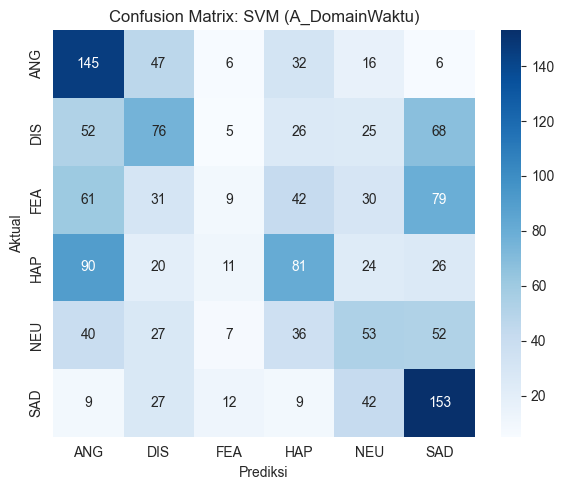

Confusion matrix disimpan ke 'confmat_SVM_A_DomainWaktu.png'

>> Confusion Matrix — RandomForest (A_DomainWaktu)
   Penjelasan: Baris = label aktual, kolom = label prediksi. Nilai di luar diagonal menunjukkan jenis kesalahan; nilai di diagonal adalah prediksi benar.


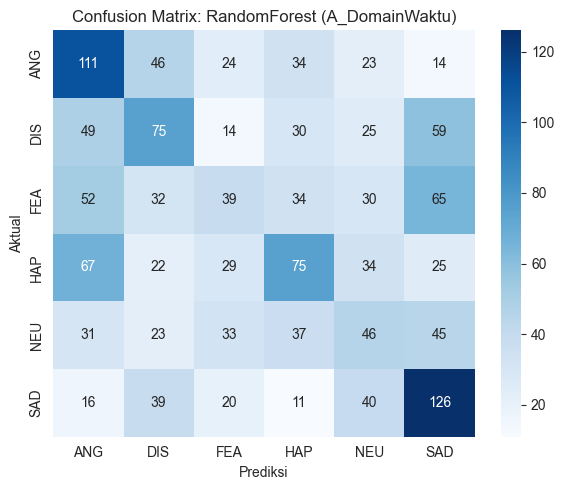

Confusion matrix disimpan ke 'confmat_RandomForest_A_DomainWaktu.png'

>> Memulai eksperimen skenario B_MFCC
   Penjelasan: Menggunakan 78 kolom fitur untuk melatih SVM dan Random Forest.

>> Hasil evaluasi SVM pada skenario 'B_MFCC'
   Penjelasan: Accuracy = persentase prediksi benar keseluruhan. Precision = dari semua prediksi suatu kelas, berapa persen benar. Recall = dari semua data aktual suatu kelas, berapa persen terdeteksi. F1 = rata-rata harmonik precision & recall, lebih adil saat data antar kelas tidak seimbang.
Accuracy : 0.4617
Precision (macro): 0.4568
Recall    (macro): 0.4589
F1-score  (macro): 0.4474

>> Classification report per kelas
   Penjelasan: Precision/recall/F1 untuk SETIAP kelas emosi secara terpisah, agar terlihat kelas mana yang paling sulit dikenali model.
              precision    recall  f1-score   support

         ANG       0.49      0.85      0.62       252
         DIS       0.42      0.41      0.42       252
         FEA       0.40      0.34      0

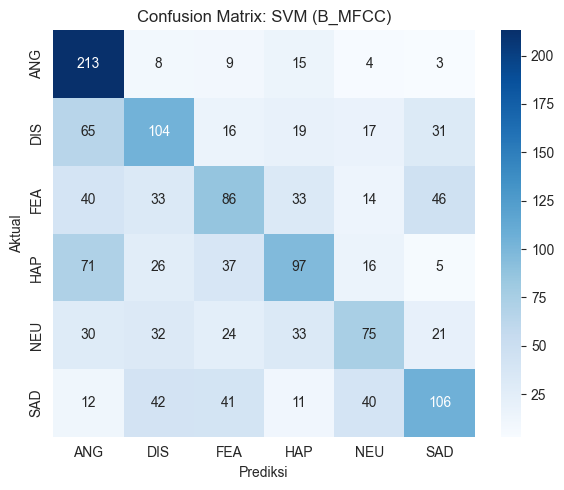

Confusion matrix disimpan ke 'confmat_SVM_B_MFCC.png'

>> Confusion Matrix — RandomForest (B_MFCC)
   Penjelasan: Baris = label aktual, kolom = label prediksi. Nilai di luar diagonal menunjukkan jenis kesalahan; nilai di diagonal adalah prediksi benar.


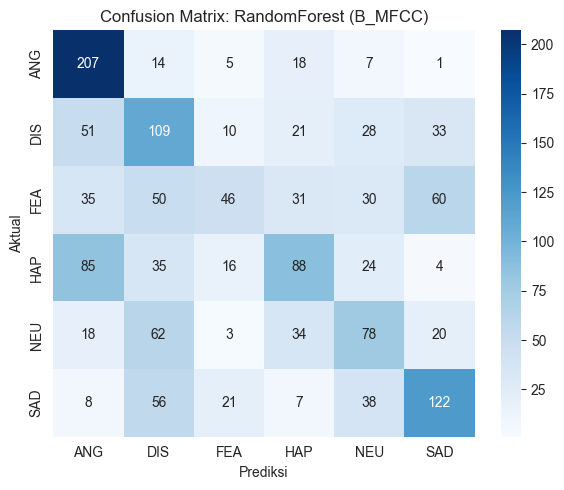

Confusion matrix disimpan ke 'confmat_RandomForest_B_MFCC.png'

>> Memulai eksperimen skenario C_Kombinasi
   Penjelasan: Menggunakan 88 kolom fitur untuk melatih SVM dan Random Forest.

>> Hasil evaluasi SVM pada skenario 'C_Kombinasi'
   Penjelasan: Accuracy = persentase prediksi benar keseluruhan. Precision = dari semua prediksi suatu kelas, berapa persen benar. Recall = dari semua data aktual suatu kelas, berapa persen terdeteksi. F1 = rata-rata harmonik precision & recall, lebih adil saat data antar kelas tidak seimbang.
Accuracy : 0.4692
Precision (macro): 0.4654
Recall    (macro): 0.4668
F1-score  (macro): 0.4561

>> Classification report per kelas
   Penjelasan: Precision/recall/F1 untuk SETIAP kelas emosi secara terpisah, agar terlihat kelas mana yang paling sulit dikenali model.
              precision    recall  f1-score   support

         ANG       0.50      0.84      0.63       252
         DIS       0.46      0.39      0.42       252
         FEA       0.42      0.38    

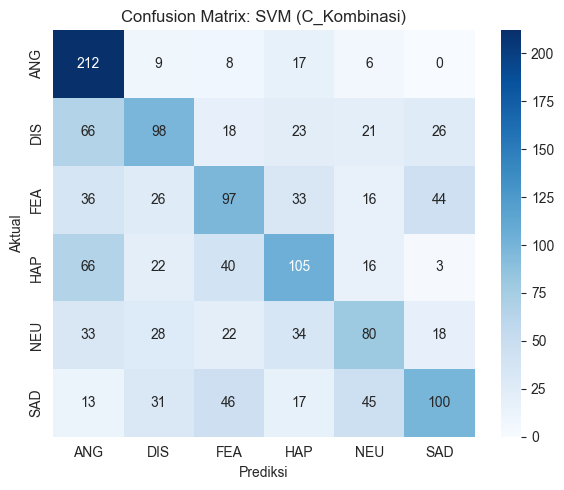

Confusion matrix disimpan ke 'confmat_SVM_C_Kombinasi.png'

>> Confusion Matrix — RandomForest (C_Kombinasi)
   Penjelasan: Baris = label aktual, kolom = label prediksi. Nilai di luar diagonal menunjukkan jenis kesalahan; nilai di diagonal adalah prediksi benar.


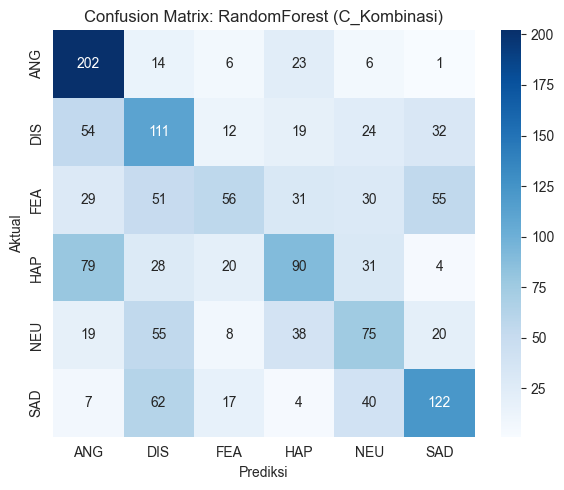

Confusion matrix disimpan ke 'confmat_RandomForest_C_Kombinasi.png'


In [24]:
all_results, scalers_per_scenario, label_encoder = run_all_scenarios(
    df_train, df_test, time_cols, freq_cols, mfcc_cols
)

In [25]:
def build_comparison_table(all_results):
    rows = []
    for r in all_results:
        rows.append({
            "Model": r["model"], "Skenario": r["scenario"],
            "Accuracy": round(r["accuracy"], 4),
            "Precision": round(r["precision"], 4),
            "Recall": round(r["recall"], 4),
            "F1-score": round(r["f1"], 4),
        })
    df_compare = pd.DataFrame(rows)

    explain(
        "Tabel perbandingan seluruh skenario & model",
        "Bandingkan baris-baris ini untuk melihat skenario fitur (A/B/C) dan "
        "model (SVM/RF) mana yang memberi performa terbaik."
    )
    display(df_compare)
    df_compare.to_csv("tabel_perbandingan_skenario.csv", index=False)
    print("\nTabel disimpan ke 'tabel_perbandingan_skenario.csv'")
    return df_compare

df_compare = build_comparison_table(all_results)


>> Tabel perbandingan seluruh skenario & model
   Penjelasan: Bandingkan baris-baris ini untuk melihat skenario fitur (A/B/C) dan model (SVM/RF) mana yang memberi performa terbaik.


,Model,Skenario,Accuracy,Precision,Recall,F1-score
0,SVM,A_DomainWaktu,0.3505,0.3191,0.3480,0.3175
1,RandomForest,A_DomainWaktu,0.3200,0.3085,0.3174,0.3084
2,SVM,B_MFCC,0.4617,0.4568,0.4589,0.4474
3,RandomForest,B_MFCC,0.4407,0.4389,0.4388,0.4211
4,SVM,C_Kombinasi,0.4692,0.4654,0.4668,0.4561
5,RandomForest,C_Kombinasi,0.4447,0.4431,0.4424,0.4285



Tabel disimpan ke 'tabel_perbandingan_skenario.csv'



>> Grafik perbandingan Accuracy & F1-score antar skenario
   Penjelasan: Memudahkan melihat secara visual skenario mana yang paling unggul.


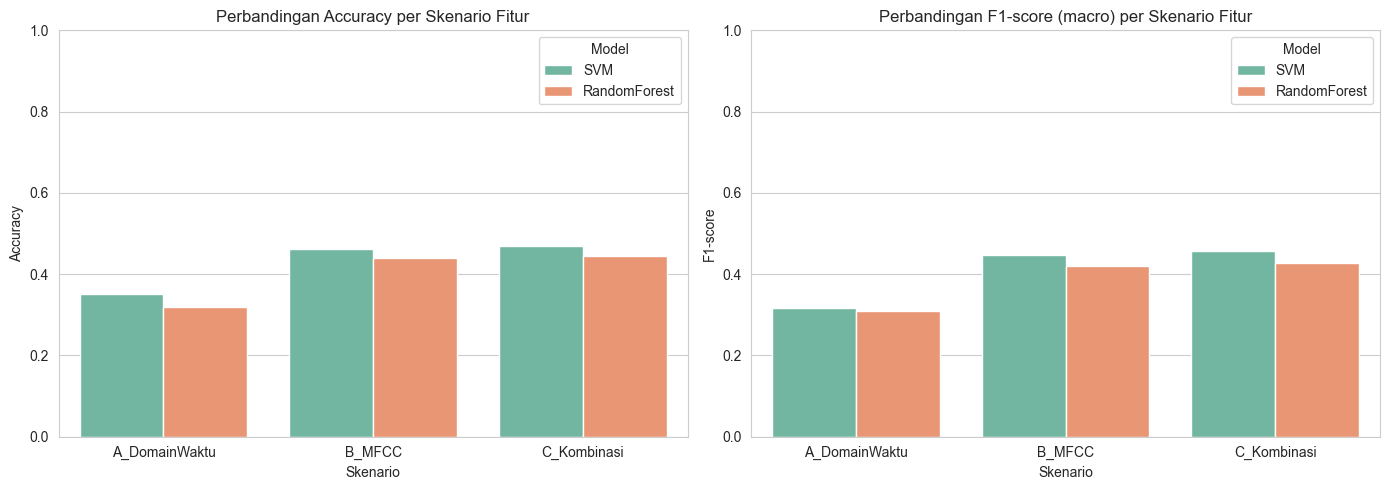


Grafik perbandingan disimpan ke 'perbandingan_skenario.png'


In [26]:
def plot_comparison(df_compare):
    explain(
        "Grafik perbandingan Accuracy & F1-score antar skenario",
        "Memudahkan melihat secara visual skenario mana yang paling unggul."
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=df_compare, x="Skenario", y="Accuracy", hue="Model", ax=axes[0], palette="Set2")
    axes[0].set_title("Perbandingan Accuracy per Skenario Fitur")
    axes[0].set_ylim(0, 1)

    sns.barplot(data=df_compare, x="Skenario", y="F1-score", hue="Model", ax=axes[1], palette="Set2")
    axes[1].set_title("Perbandingan F1-score (macro) per Skenario Fitur")
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.savefig("perbandingan_skenario.png", dpi=150)
    plt.show()
    print("\nGrafik perbandingan disimpan ke 'perbandingan_skenario.png'")

plot_comparison(df_compare)

## 6. CNN pada Mel Spectrogram — Justifikasi Detail Arsitektur

Mel-Spectrogram
berbentuk **R^(T x F)** -- representasi 2D dengan dimensi waktu (T) dan
frekuensi-mel (F) -- dan tergolong **data sekuensial 2D**. Inilah alasan
utama memilih **CNN 2D**, bukan ML klasik langsung pada data ini (dimensinya
terlalu besar untuk SVM/RF tanpa reduksi) dan bukan CNN 1D (yang lebih cocok
untuk sinyal 1D seperti raw waveform atau FFT global).

Justifikasi setiap pilihan layer:

| Layer | Kenapa dipilih | Alternatif & kenapa tidak dipakai |
|---|---|---|
| `Conv2D` kernel 3x3 | Menangkap pola LOKAL pada bidang waktu-frekuensi (mirip formant/pola energi pada Mel Spectrogram), sesuai poin slide "CNN dapat menangkap pola lokal dalam domain frekuensi". 3x3 adalah ukuran standar yang cukup kecil untuk efisien namun tetap menangkap konteks tetangga. | Kernel 5x5/7x7 menangkap konteks lebih luas tapi parameter jauh lebih banyak -> risiko overfitting lebih tinggi untuk dataset kecil. Kernel 1x1 tidak menangkap pola spasial sama sekali. |
| `BatchNormalization` | Menstabilkan distribusi aktivasi antar layer selama training, mempercepat konvergensi, dan punya efek regularisasi ringan (mengurangi overfitting). | Tanpa ini, training lebih lambat konvergen dan lebih sensitif terhadap learning rate. |
| `MaxPooling2D (2x2)` | Mereduksi dimensi spasial (downsampling) sekaligus membuat fitur lebih invariant terhadap pergeseran kecil posisi pola di waktu/frekuensi -- penting karena ucapan yang sama bisa sedikit bergeser waktunya antar rekaman. | `AveragePooling2D` meratakan informasi (bisa menghilangkan puncak energi penting); tanpa pooling sama sekali, jumlah parameter di layer Dense akan meledak. |
| `Dropout` (0.3/0.4/0.5 bertingkat) | Mematikan sebagian neuron secara acak saat training agar model tidak terlalu bergantung pada kombinasi neuron tertentu (anti-overfitting), rate dinaikkan di layer lebih dalam karena representasi di situ lebih abstrak & rawan menghafal. | Rate terlalu tinggi di awal (sebelum Conv pertama) bisa merusak informasi mentah yang belum terbentuk. |
| `kernel_regularizer=L2` | Menahan bobot agar tidak tumbuh terlalu besar, mencegah model "menghafal" pola spesifik training (anti-overfitting tambahan di luar Dropout). | L1 regularization cenderung membuat bobot menjadi nol (sparsity) yang kurang relevan di sini; tanpa regularisasi sama sekali, bobot bebas membesar tanpa kendali. |
| `Flatten` + `Dense(128)` | Mengubah fitur spasial 2D hasil Conv menjadi vektor 1D untuk diproses layer klasifikasi penuh (fully connected), 128 unit dipilih sebagai ukuran menengah -- cukup besar untuk menangkap kombinasi fitur, tidak terlalu besar untuk dataset relatif kecil. | `GlobalAveragePooling2D` sebagai alternatif Flatten akan mengurangi parameter lebih jauh (opsi lanjutan jika overfitting masih terjadi). |
| `Dense(n_classes, activation="softmax")` | Output akhir berupa distribusi probabilitas atas seluruh kelas emosi (saling eksklusif, totalnya 1) -- standar untuk klasifikasi multi-kelas. | `sigmoid` per kelas dipakai untuk multi-LABEL (satu sampel bisa punya >1 label), tidak sesuai di sini karena satu audio = satu emosi. |
| `loss="sparse_categorical_crossentropy"` | Cocok untuk label berupa integer (hasil `LabelEncoder`) dengan kelas saling eksklusif; secara matematis mengukur seberapa jauh distribusi probabilitas prediksi dari label sebenarnya. | `categorical_crossentropy` butuh label dalam format one-hot (sebenarnya setara secara matematis, hanya beda format input). |
| `optimizer="adam"` | Adaptive learning rate per parameter, secara empiris konvergen lebih cepat dan stabil dibanding SGD murni untuk kebanyakan task deep learning, termasuk audio. | `SGD` lebih lambat konvergen dan butuh tuning learning rate lebih hati-hati; `RMSprop` mirip Adam namun Adam umumnya jadi pilihan default yang lebih robust. |
| `EarlyStopping(patience=5, restore_best_weights=True)` | Menghentikan training otomatis begitu `val_loss` tidak membaik 5 epoch berturut-turut, dan mengembalikan bobot terbaik (bukan bobot di epoch terakhir yang mungkin sudah overfit). | Tanpa ini, harus menebak jumlah epoch ideal secara manual, yang berisiko underfitting (terlalu sedikit) atau overfitting (terlalu banyak). |


In [27]:
def plot_training_history(history):
    explain(
        "Kurva training history CNN",
        "Jika 'Validation' mulai memburuk (loss naik / accuracy turun) sementara "
        "'Train' masih membaik, itu tanda overfitting. EarlyStopping otomatis "
        "menghentikan training sebelum kondisi ini parah."
    )
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["accuracy"], label="Train")
    axes[0].plot(history.history["val_accuracy"], label="Validation")
    axes[0].set_title("Akurasi CNN per Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="Train")
    axes[1].plot(history.history["val_loss"], label="Validation")
    axes[1].set_title("Loss CNN per Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("cnn_training_history.png", dpi=150)
    plt.show()
    print("\nGrafik training history CNN disimpan ke 'cnn_training_history.png'")

In [28]:
# ======================================================================
# FUNGSI: build_and_train_cnn
# ----------------------------------------------------------------------
# Tujuan: Membangun & melatih CNN untuk klasifikasi emosi dari Mel
# Spectrogram. epochs=50 hanya batas MAKSIMUM — EarlyStopping akan
# menghentikan training lebih awal begitu val_loss tidak membaik lagi,
# supaya tidak overfitting dan tidak perlu menebak jumlah epoch ideal.
# ======================================================================
def build_and_train_cnn(mel_train, labels_train, mel_test, labels_test, epochs=50):
    # Import dilakukan di dalam fungsi (bukan di atas file) supaya TensorFlow
    # hanya dimuat saat fungsi ini benar-benar dipanggil -- mempercepat waktu
    # import notebook secara keseluruhan jika CNN belum dijalankan.
    import tensorflow as tf
    from tensorflow.keras import layers, models

    # ------------------------------------------------------------------
    # KONFIGURASI GPU/CPU
    # ------------------------------------------------------------------
    # FORCE_CPU=True  -> paksa training berjalan di CPU saja (lebih lambat,
    #                    tapi paling aman jika GPU bermasalah/driver tidak cocok).
    # GPU_MEMORY_LIMIT_MB -> jika diisi angka (misal 2048), GPU dibatasi hanya
    #                    boleh memakai sejumlah itu (dalam MB), mencegah TensorFlow
    #                    menyita seluruh VRAM dan bertabrakan dengan proses lain.
    #                    Jika None, dipakai mode 'memory_growth' (alokasi bertahap).
    FORCE_CPU = False
    GPU_MEMORY_LIMIT_MB = 4000  # contoh: 2048 untuk membatasi ke 2GB

    if FORCE_CPU:
        # Menyembunyikan semua device GPU dari TensorFlow, sehingga otomatis
        # fallback ke CPU untuk seluruh komputasi di fungsi ini.
        tf.config.set_visible_devices([], "GPU")
        print("CNN dipaksa berjalan di CPU (FORCE_CPU=True).")
    else:
        gpus = tf.config.list_physical_devices("GPU")
        for gpu in gpus:
            try:
                if GPU_MEMORY_LIMIT_MB is not None:
                    # Batasi VRAM yang boleh dipakai TensorFlow secara eksplisit.
                    tf.config.set_logical_device_configuration(
                        gpu, [tf.config.LogicalDeviceConfiguration(memory_limit=GPU_MEMORY_LIMIT_MB)]
                    )
                else:
                    # 'memory_growth': GPU tidak langsung disita semua di awal,
                    # melainkan dialokasikan bertahap sesuai kebutuhan aktual.
                    tf.config.experimental.set_memory_growth(gpu, True)
            except RuntimeError as e:
                # Biasanya muncul jika GPU sudah terinisialisasi sebelumnya
                # (misalnya sel ini dijalankan ulang tanpa restart kernel).
                print(f"Gagal konfigurasi GPU (mungkin sudah terinisialisasi): {e}")

    # ------------------------------------------------------------------
    # ENCODING LABEL
    # ------------------------------------------------------------------
    # Label emosi berupa string (mis. 'HAP', 'SAD') diubah menjadi integer
    # (0, 1, 2, ...) karena layer output Dense + loss function mengharapkan
    # label numerik, bukan teks.
    le_cnn = LabelEncoder()
    y_train = le_cnn.fit_transform(labels_train)
    y_test = le_cnn.transform(labels_test)

    # ------------------------------------------------------------------
    # RENDER JUMLAH DATA TRAIN & TEST SEBELUM TRAINING DIMULAI
    # ------------------------------------------------------------------
    # Penting dicek SEBELUM training: memastikan jumlah sampel train/test
    # sesuai ekspektasi (tidak ada file yang gagal diproses sebelumnya),
    # dan melihat distribusi kelas -- kelas yang sangat sedikit jumlahnya
    # akan lebih sulit dipelajari model.
    explain(
        "Jumlah data TRAIN dan TEST sebelum training CNN dimulai",
        "Memastikan jumlah sampel sesuai ekspektasi dan melihat distribusi "
        "kelas emosi pada masing-masing split, sebelum proses training "
        "yang memakan waktu lama dijalankan."
    )
    print(f"Jumlah sampel TRAIN : {len(labels_train)}")
    print(f"Jumlah sampel TEST  : {len(labels_test)}")
    print(f"Jumlah kelas emosi  : {len(le_cnn.classes_)} -> {list(le_cnn.classes_)}")
    print("\nDistribusi kelas pada data TRAIN:")
    print(pd.Series(labels_train).value_counts())
    print("\nDistribusi kelas pada data TEST:")
    print(pd.Series(labels_test).value_counts())

    # ------------------------------------------------------------------
    # NORMALISASI MEL SPECTROGRAM
    # ------------------------------------------------------------------
    # Nilai asli Mel Spectrogram dalam skala dB (bisa negatif, rentang lebar).
    # Dinormalisasi ke rentang [0, 1] (min-max scaling) agar training CNN
    # lebih stabil -- jaringan saraf umumnya belajar lebih baik saat input
    # berada dalam rentang nilai yang kecil dan konsisten.
    X_train = (mel_train - mel_train.min()) / (mel_train.max() - mel_train.min())
    X_test = (mel_test - mel_test.min()) / (mel_test.max() - mel_test.min())

    # Menambahkan dimensi channel di akhir (shape: [N, 128, 174] -> [N, 128, 174, 1])
    # karena Conv2D Keras mengharapkan input berbentuk (batch, height, width, channel),
    # mirip gambar grayscale dengan 1 channel warna.
    X_train = X_train[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    n_classes = len(le_cnn.classes_)
    input_shape = X_train.shape[1:]  # contoh: (128, 174, 1)

    # ------------------------------------------------------------------
    # ARSITEKTUR CNN
    # ------------------------------------------------------------------
    # Lihat tabel justifikasi arsitektur di markdown sebelum sel ini untuk
    # penjelasan detail kenapa setiap layer dipilih.
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Blok Conv pertama: 32 filter, kernel 3x3, menangkap pola LOKAL
        # sederhana (mis. tepi energi pada bidang waktu-frekuensi).
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        # MaxPooling memperkecil ukuran spasial (downsampling) sekaligus
        # membuat fitur lebih tahan terhadap pergeseran kecil posisi pola.
        layers.MaxPooling2D((2, 2)),

        # Blok Conv kedua: 64 filter (lebih banyak dari blok pertama), karena
        # di layer yang lebih dalam, kombinasi pola yang perlu ditangkap
        # menjadi lebih kompleks (gabungan pola-pola dari blok pertama).
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Flatten mengubah output 2D (hasil Conv+Pooling) menjadi vektor 1D
        # agar bisa diproses oleh layer Dense (fully connected) di bawahnya.
        layers.Flatten(),
        # Dense(128): layer fully-connected untuk mengombinasikan seluruh
        # fitur spasial yang sudah diekstrak menjadi representasi tingkat tinggi.
        layers.Dense(128, activation="relu"),
        # Dropout(0.3): mematikan 30%% neuron secara acak saat training untuk
        # mencegah model terlalu bergantung pada kombinasi neuron tertentu
        # (salah satu teknik anti-overfitting paling dasar).
        layers.Dropout(0.3),
        # Layer output: jumlah neuron = jumlah kelas emosi, activation softmax
        # menghasilkan distribusi probabilitas yang totalnya selalu 1.
        layers.Dense(n_classes, activation="softmax"),
    ])

    # optimizer="adam": adaptive learning rate, pilihan default yang stabil
    #   untuk kebanyakan task deep learning.
    # loss="sparse_categorical_crossentropy": cocok untuk label berbentuk
    #   integer (bukan one-hot) dengan kelas yang saling eksklusif.
    # metrics=["accuracy"]: metrik yang dipantau selama training/validasi.
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    explain(
        "Ringkasan arsitektur CNN",
        "Menunjukkan urutan layer dan jumlah parameter yang akan dilatih. "
        "Semakin banyak parameter, semakin besar kapasitas model untuk "
        "belajar, tapi juga semakin besar risiko overfitting jika data sedikit."
    )
    model.summary()

    # ------------------------------------------------------------------
    # EARLY STOPPING
    # ------------------------------------------------------------------
    # Memantau val_loss (loss pada data validasi/test). Jika tidak ada
    # perbaikan selama 5 epoch berturut-turut ('patience'), training
    # dihentikan otomatis. restore_best_weights=True memastikan model
    # akhir memakai bobot terbaik selama training, bukan bobot di epoch
    # terakhir (yang mungkin sudah mulai overfitting).
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )

    # ------------------------------------------------------------------
    # TRAINING
    # ------------------------------------------------------------------
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                         epochs=epochs, batch_size=32, verbose=1,
                         callbacks=[early_stop])

    # ------------------------------------------------------------------
    # EVALUASI PADA DATA TEST
    # ------------------------------------------------------------------
    # predict dilakukan dengan batch_size=8 juga (bukan sekaligus untuk
    # seluruh data test), untuk mencegah error OOM saat alokasi tensor
    # besar di GPU/CPU dengan memori terbatas.
    y_pred = np.argmax(model.predict(X_test, batch_size=8), axis=1)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")

    explain(
        "Hasil evaluasi CNN pada data test",
        "Bandingkan angka-angka ini dengan hasil SVM/RF skenario kombinasi (C) "
        "untuk melihat apakah CNN benar-benar unggul dibanding fitur hand-crafted."
    )
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall    (macro): {recall:.4f}")
    print(f"F1-score  (macro): {f1:.4f}")
    # classification_report menampilkan precision/recall/F1 PER KELAS,
    # berguna untuk melihat kelas emosi mana yang paling sulit dikenali.
    print(classification_report(y_test, y_pred, target_names=le_cnn.classes_))

    # Confusion matrix: tabel silang antara label aktual vs prediksi,
    # menunjukkan pola kesalahan klasifikasi secara visual.
    cm = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix({"model": "CNN", "scenario": "MelSpectrogram",
                            "confusion_matrix": cm, "labels": le_cnn.classes_})

    # Kurva accuracy/loss per epoch, untuk memeriksa indikasi overfitting
    # (gap besar antara train dan validation) atau underfitting (keduanya
    # stuck di nilai yang sama, tidak membaik).
    plot_training_history(history)

    # Dictionary hasil dikembalikan agar bisa dibandingkan dengan hasil
    # SVM/RF pada tabel perbandingan final di bagian akhir notebook.
    return {"model": "CNN", "scenario": "MelSpectrogram",
            "accuracy": acc, "precision": precision, "recall": recall, "f1": f1,
            "trained_model": model, "label_encoder": le_cnn}


>> Jumlah data TRAIN dan TEST sebelum training CNN dimulai
   Penjelasan: Memastikan jumlah sampel sesuai ekspektasi dan melihat distribusi kelas emosi pada masing-masing split, sebelum proses training yang memakan waktu lama dijalankan.
Jumlah sampel TRAIN : 5967
Jumlah sampel TEST  : 1475
Jumlah kelas emosi  : 6 -> ['ANG', 'DIS', 'FEA', 'HAP', 'NEU', 'SAD']

Distribusi kelas pada data TRAIN:
ANG    1019
DIS    1019
FEA    1019
HAP    1019
SAD    1019
NEU     872
Name: count, dtype: int64

Distribusi kelas pada data TEST:
ANG    252
DIS    252
FEA    252
HAP    252
SAD    252
NEU    215
Name: count, dtype: int64

>> Ringkasan arsitektur CNN
   Penjelasan: Menunjukkan urutan layer dan jumlah parameter yang akan dilatih. Semakin banyak parameter, semakin besar kapasitas model untuk belajar, tapi juga semakin besar risiko overfitting jika data sedikit.
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape         

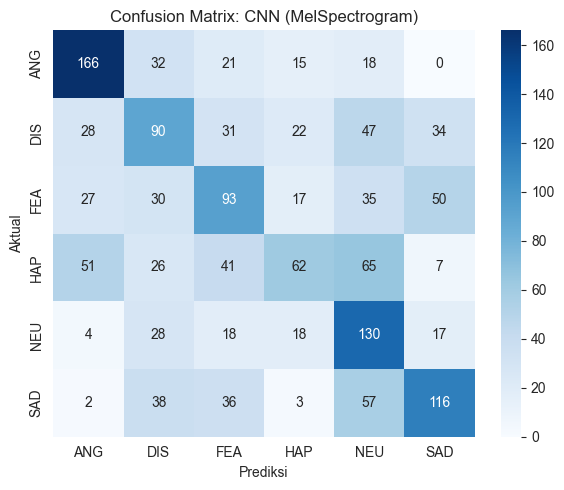

Confusion matrix disimpan ke 'confmat_CNN_MelSpectrogram.png'

>> Kurva training history CNN
   Penjelasan: Jika 'Validation' mulai memburuk (loss naik / accuracy turun) sementara 'Train' masih membaik, itu tanda overfitting. EarlyStopping otomatis menghentikan training sebelum kondisi ini parah.


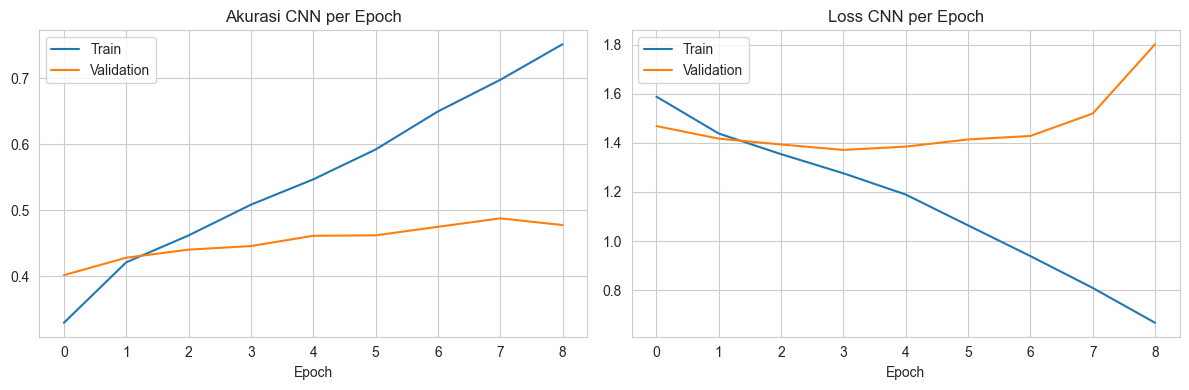


Grafik training history CNN disimpan ke 'cnn_training_history.png'


In [29]:
mel_train = np.load("melspec_train.npy")
mel_test = np.load("melspec_test.npy")
labels_train_arr = np.load("labels_train.npy", allow_pickle=True)
labels_test_arr = np.load("labels_test.npy", allow_pickle=True)

cnn_result = build_and_train_cnn(mel_train, labels_train_arr, mel_test, labels_test_arr, epochs=20)

### 6.1 Tabel Perbandingan Akhir (SVM, Random Forest, CNN)

In [30]:
df_final = pd.concat([df_compare, pd.DataFrame([{
    "Model": cnn_result["model"], "Skenario": cnn_result["scenario"],
    "Accuracy": round(cnn_result["accuracy"], 4),
    "Precision": round(cnn_result["precision"], 4),
    "Recall": round(cnn_result["recall"], 4),
    "F1-score": round(cnn_result["f1"], 4),
}])], ignore_index=True)

explain(
    "Tabel perbandingan FINAL termasuk CNN",
    "Ringkasan akhir untuk bagian Analisis: domain waktu saja vs MFCC saja vs "
    "kombinasi semua fitur (SVM & RF), dibandingkan lagi dengan CNN."
)
display(df_final)
df_final.to_csv("tabel_perbandingan_final.csv", index=False)
print("\nTabel final disimpan ke 'tabel_perbandingan_final.csv'")


>> Tabel perbandingan FINAL termasuk CNN
   Penjelasan: Ringkasan akhir untuk bagian Analisis: domain waktu saja vs MFCC saja vs kombinasi semua fitur (SVM & RF), dibandingkan lagi dengan CNN.


,Model,Skenario,Accuracy,Precision,Recall,F1-score
0,SVM,A_DomainWaktu,0.3505,0.3191,0.3480,0.3175
1,RandomForest,A_DomainWaktu,0.3200,0.3085,0.3174,0.3084
2,SVM,B_MFCC,0.4617,0.4568,0.4589,0.4474
3,RandomForest,B_MFCC,0.4407,0.4389,0.4388,0.4211
4,SVM,C_Kombinasi,0.4692,0.4654,0.4668,0.4561
5,RandomForest,C_Kombinasi,0.4447,0.4431,0.4424,0.4285
6,CNN,MelSpectrogram,0.4454,0.4489,0.4493,0.4387



Tabel final disimpan ke 'tabel_perbandingan_final.csv'


## 7. Ekspor Model ke `.pkl` untuk Streamlit App

Yang disimpan: model SVM & Random Forest skenario **C (Kombinasi)**,
`StandardScaler`, `LabelEncoder`, dan daftar kolom fitur. CNN disimpan
terpisah sebagai `cnn_model.keras` (format pickle tidak cocok untuk model
TensorFlow/Keras).

In [31]:
def export_models_for_streamlit(all_results, scalers_per_scenario, label_encoder,
                                  scenario_used="C_Kombinasi"):
    svm_c = next(r for r in all_results if r["model"] == "SVM" and r["scenario"] == scenario_used)
    rf_c = next(r for r in all_results if r["model"] == "RandomForest" and r["scenario"] == scenario_used)
    scaler_c, feature_cols_c = scalers_per_scenario[scenario_used]

    bundle = {
        "svm_model": svm_c["trained_model"],
        "rf_model": rf_c["trained_model"],
        "scaler": scaler_c,
        "label_encoder": label_encoder,
        "feature_columns": feature_cols_c,
        "scenario": scenario_used,
        "config": {
            "SR": SR, "N_MFCC": N_MFCC, "N_MELS": N_MELS,
            "MAX_PAD_LEN": MAX_PAD_LEN, "FIXED_DURATION": FIXED_DURATION, "TOP_DB": TOP_DB,
            "FRAME_LENGTH": FRAME_LENGTH, "HOP_LENGTH": HOP_LENGTH,
        },
    }

    with open("model_bundle.pkl", "wb") as f:
        pickle.dump(bundle, f)
    joblib.dump(bundle, "model_bundle.joblib.pkl")

    explain(
        "File model_bundle.pkl berhasil disimpan",
        "Berisi SVM, Random Forest, scaler, label encoder, dan daftar kolom "
        "fitur skenario kombinasi, untuk dimuat ulang di aplikasi Streamlit."
    )
    print("Disimpan ke 'model_bundle.pkl' dan 'model_bundle.joblib.pkl'")
    print("Isi bundle:", list(bundle.keys()))
    print(f"Jumlah kolom fitur yang dipakai: {len(feature_cols_c)}")

    return bundle

bundle = export_models_for_streamlit(all_results, scalers_per_scenario, label_encoder)


>> File model_bundle.pkl berhasil disimpan
   Penjelasan: Berisi SVM, Random Forest, scaler, label encoder, dan daftar kolom fitur skenario kombinasi, untuk dimuat ulang di aplikasi Streamlit.
Disimpan ke 'model_bundle.pkl' dan 'model_bundle.joblib.pkl'
Isi bundle: ['svm_model', 'rf_model', 'scaler', 'label_encoder', 'feature_columns', 'scenario', 'config']
Jumlah kolom fitur yang dipakai: 88


In [32]:
cnn_result["trained_model"].save("cnn_model.keras")

explain(
    "Model CNN disimpan ke 'cnn_model.keras'",
    "Di Streamlit, model ini dimuat dengan tensorflow.keras.models.load_model('cnn_model.keras')."
)

with open("cnn_label_encoder.pkl", "wb") as f:
    pickle.dump(cnn_result["label_encoder"], f)

print("Label encoder CNN disimpan ke 'cnn_label_encoder.pkl'")


>> Model CNN disimpan ke 'cnn_model.keras'
   Penjelasan: Di Streamlit, model ini dimuat dengan tensorflow.keras.models.load_model('cnn_model.keras').
Label encoder CNN disimpan ke 'cnn_label_encoder.pkl'


## 8. Analisis

### 8.1 Tabel Hasil Akhir (urutan terbaru, termasuk CNN)

| Model | Skenario | Accuracy | Precision | Recall | F1-score |
|---|---|---|---|---|---|
| SVM | **C_Kombinasi** | **0.4692** | **0.4654** | **0.4668** | **0.4561** |
| SVM | B_MFCC | 0.4617 | 0.4568 | 0.4589 | 0.4474 |
| CNN | MelSpectrogram | 0.4454 | 0.4489 | 0.4493 | 0.4387 |
| RandomForest | C_Kombinasi | 0.4447 | 0.4431 | 0.4424 | 0.4285 |
| RandomForest | B_MFCC | 0.4407 | 0.4389 | 0.4388 | 0.4211 |
| SVM | A_DomainWaktu | 0.3505 | 0.3191 | 0.3480 | 0.3175 |
| RandomForest | A_DomainWaktu | 0.3200 | 0.3085 | 0.3174 | 0.3084 |

### 8.2 Perbandingan Skenario Fitur (A vs B vs C)

Pola sebelumnya tetap konsisten: domain waktu saja (A) paling lemah
(0.32-0.35), MFCC saja (B) melonjak jauh (0.44-0.46), kombinasi (C) sedikit
lebih baik lagi untuk SVM (0.4692) meski untuk Random Forest kontribusi
fitur frekuensi tambahan nyaris flat (RF B=0.4407 vs RF C=0.4447, hanya
+0.004). Ini menguatkan kesimpulan: **MFCC tetap kontributor dominan**,
fitur domain frekuensi (centroid/bandwidth/rolloff) hanya pelengkap kecil.

### 8.3 Perbandingan SVM vs Random Forest

SVM kembali konsisten mengungguli Random Forest di setiap skenario yang
sebanding (selisih 0.020-0.030), pola yang sama dengan run sebelumnya --
memperkuat bahwa keunggulan SVM di sini bukan kebetulan satu kali run,
melainkan memang karena fitur tabular (terutama MFCC yang sudah di-scale)
lebih cocok dengan karakteristik SVM dibanding Random Forest pada skala
dataset ini.

### 8.4 CNN vs ML Klasik (Update Penting)

Pada run kali ini, **CNN (0.4454) sedikit mengungguli Random Forest skenario
kombinasi (0.4447)** -- meski selisihnya sangat kecil (+0.0007, bisa
dianggap setara/tidak signifikan secara statistik) -- namun CNN **masih
tetap di bawah SVM** baik skenario MFCC (0.4617) maupun Kombinasi (0.4692).
Dari log training: training dihentikan otomatis oleh EarlyStopping di
**epoch ke-9 dari 20**, dengan val_loss terbaik tercatat di **epoch ke-4**
(1.3710) sebelum naik kembali sampai 1.8016 di epoch 9 -- pola overfitting
yang sama seperti run sebelumnya, hanya titik baliknya sedikit lebih lambat
(epoch 4, dibanding epoch 2 pada run sebelumnya). Train accuracy terus naik
tajam ke 0.7513 sementara val_accuracy stagnan di kisaran 0.40-0.49,
menegaskan kembali bahwa CNN cepat menghafal data training pada dataset
sebesar ini.

**Kesimpulan yang tidak berubah:** CNN tidak terbukti unggul signifikan
dibanding pendekatan ML klasik (khususnya SVM) untuk dataset Crema berskala
ini, konsisten di dua kali run terpisah dengan konfigurasi training yang
sedikit berbeda (epochs/batch_size).

### 8.5 Kesimpulan Akhir

Rekomendasi tidak berubah dari analisis sebelumnya: **SVM skenario
Kombinasi (C)** tetap pilihan terbaik untuk dipakai di aplikasi Streamlit --
accuracy dan F1-score tertinggi di antara seluruh kombinasi yang diuji,
sekaligus lebih ringan untuk inferensi dibanding CNN. Stabilitas hasil ini
(SVM C tetap juara di run pertama maupun kedua) memberi keyakinan lebih
tinggi bahwa kesimpulan ini bukan kebetulan dari satu kali eksperimen.

In [40]:
df_eval = pd.read_csv("tabel_perbandingan_final.csv")

best_overall = df_eval.loc[df_eval["Accuracy"].idxmax()]
cnn_row = df_eval[df_eval["Model"] == "CNN"].iloc[0]
rf_c_row = df_eval[(df_eval["Model"] == "RandomForest") & (df_eval["Skenario"] == "C_Kombinasi")].iloc[0]

explain(
    "Tabel hasil akhir terbaru (diurutkan berdasarkan Accuracy)",
    "SVM skenario Kombinasi tetap di posisi pertama, CNN naik tipis "
    "melewati Random Forest Kombinasi dibanding run sebelumnya."
)
display(df_eval.sort_values("Accuracy", ascending=False).reset_index(drop=True))

print(f"\nModel terbaik: {best_overall['Model']} ({best_overall['Skenario']}) "
      f"-> Accuracy={best_overall['Accuracy']:.4f}, F1={best_overall['F1-score']:.4f}")
print(f"\nCNN vs RandomForest (Kombinasi): "
      f"CNN={cnn_row['Accuracy']:.4f} vs RF={rf_c_row['Accuracy']:.4f} "
      f"(selisih: {cnn_row['Accuracy'] - rf_c_row['Accuracy']:+.4f})")


>> Tabel hasil akhir terbaru (diurutkan berdasarkan Accuracy)
   Penjelasan: SVM skenario Kombinasi tetap di posisi pertama, CNN naik tipis melewati Random Forest Kombinasi dibanding run sebelumnya.


,Model,Skenario,Accuracy,Precision,Recall,F1-score
0,SVM,C_Kombinasi,0.4692,0.4654,0.4668,0.4561
1,SVM,B_MFCC,0.4617,0.4568,0.4589,0.4474
2,CNN,MelSpectrogram,0.4454,0.4489,0.4493,0.4387
3,RandomForest,C_Kombinasi,0.4447,0.4431,0.4424,0.4285
4,RandomForest,B_MFCC,0.4407,0.4389,0.4388,0.4211
5,SVM,A_DomainWaktu,0.3505,0.3191,0.3480,0.3175
6,RandomForest,A_DomainWaktu,0.3200,0.3085,0.3174,0.3084



Model terbaik: SVM (C_Kombinasi) -> Accuracy=0.4692, F1=0.4561

CNN vs RandomForest (Kombinasi): CNN=0.4454 vs RF=0.4447 (selisih: +0.0007)



>> Ranking seluruh kombinasi Model x Skenario berdasarkan Accuracy
   Penjelasan: Menampilkan urutan dari yang terbaik ke terburuk, memperjelas posisi SVM Kombinasi di puncak dan jarak yang konsisten antar kelompok skenario (A jauh di bawah, B dan C berdekatan, CNN menyelip di antara).


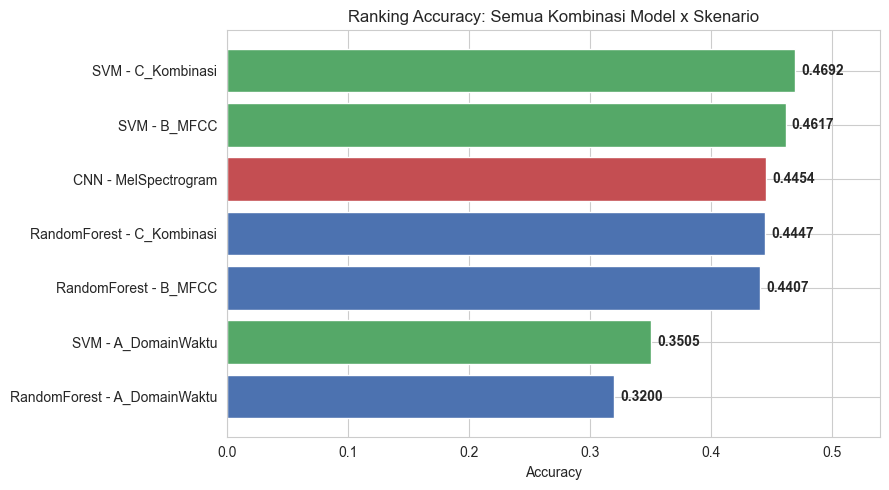


Visualisasi disimpan ke 'ranking_semua_kombinasi.png'


In [41]:
explain(
    "Ranking seluruh kombinasi Model x Skenario berdasarkan Accuracy",
    "Menampilkan urutan dari yang terbaik ke terburuk, memperjelas posisi "
    "SVM Kombinasi di puncak dan jarak yang konsisten antar kelompok "
    "skenario (A jauh di bawah, B dan C berdekatan, CNN menyelip di antara)."
)

df_sorted = df_eval.sort_values("Accuracy", ascending=True)
labels = df_sorted["Model"] + " - " + df_sorted["Skenario"]
colors = ["#55a868" if m == "SVM" else "#4c72b0" if m == "RandomForest" else "#c44e52"
          for m in df_sorted["Model"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, df_sorted["Accuracy"], color=colors)
ax.set_xlabel("Accuracy")
ax.set_title("Ranking Accuracy: Semua Kombinasi Model x Skenario")
ax.set_xlim(0, max(df_eval["Accuracy"]) * 1.15)

for bar, acc in zip(bars, df_sorted["Accuracy"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{acc:.4f}", va="center", fontweight="bold")

plt.tight_layout()
plt.savefig("ranking_semua_kombinasi.png", dpi=150)
plt.show()
print("\nVisualisasi disimpan ke 'ranking_semua_kombinasi.png'")


>> Perbandingan close-up: CNN vs Random Forest (skenario Kombinasi)
   Penjelasan: Memperbesar skala sumbu Y agar selisih kecil antara CNN dan RF terlihat jelas secara visual, sekaligus menunjukkan keduanya jauh di bawah SVM Kombinasi sebagai pembanding.


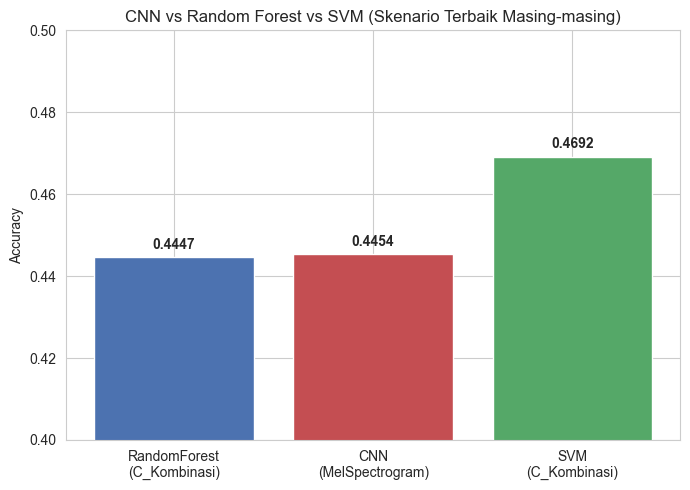


Visualisasi disimpan ke 'cnn_vs_rf_vs_svm.png'


In [42]:
cnn_row = df_eval[df_eval["Model"] == "CNN"].iloc[0]
rf_c_row = df_eval[(df_eval["Model"] == "RandomForest") & (df_eval["Skenario"] == "C_Kombinasi")].iloc[0]
best_overall = df_eval.loc[df_eval["Accuracy"].idxmax()]

explain(
    "Perbandingan close-up: CNN vs Random Forest (skenario Kombinasi)",
    "Memperbesar skala sumbu Y agar selisih kecil antara CNN dan RF "
    "terlihat jelas secara visual, sekaligus menunjukkan keduanya jauh "
    "di bawah SVM Kombinasi sebagai pembanding."
)

compare_df = pd.DataFrame({
    "Model": ["RandomForest\n(C_Kombinasi)", "CNN\n(MelSpectrogram)", "SVM\n(C_Kombinasi)"],
    "Accuracy": [rf_c_row["Accuracy"], cnn_row["Accuracy"], best_overall["Accuracy"]],
})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(compare_df["Model"], compare_df["Accuracy"],
               color=["#4c72b0", "#c44e52", "#55a868"])
ax.set_ylabel("Accuracy")
ax.set_title("CNN vs Random Forest vs SVM (Skenario Terbaik Masing-masing)")
ax.set_ylim(0.40, 0.50)

for bar, acc in zip(bars, compare_df["Accuracy"]):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.002, f"{acc:.4f}",
            ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("cnn_vs_rf_vs_svm.png", dpi=150)
plt.show()
print("\nVisualisasi disimpan ke 'cnn_vs_rf_vs_svm.png'")


>> Gap Train vs Validation Accuracy CNN (data diambil dari log training yang sudah ada)
   Penjelasan: Nilai-nilai berikut diambil langsung dari hasil log training sebelumnya (9 epoch sebelum EarlyStopping berhenti), tanpa perlu menjalankan ulang training CNN. Garis vertikal menandai epoch dengan val_loss terbaik.


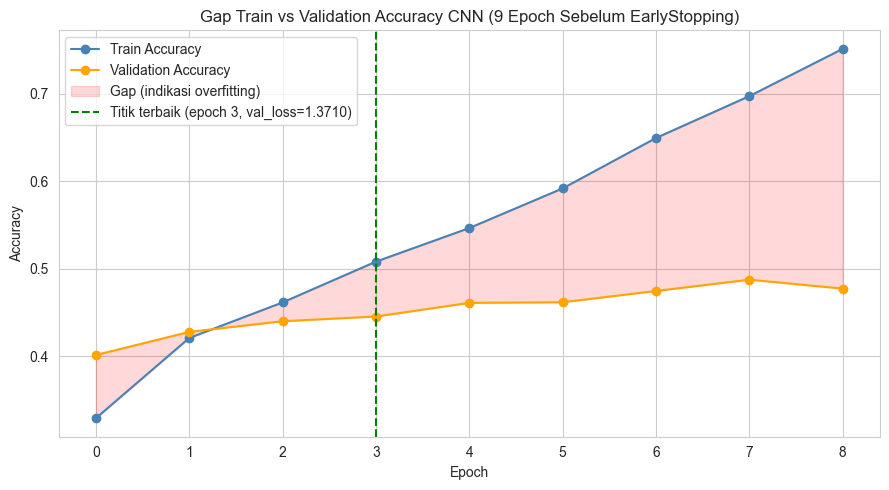


Val_loss terbaik di epoch 3 (1.3710)
Train Acc akhir (epoch 8): 0.7513
Val Acc akhir (epoch 8)  : 0.4773
Gap akhir                : 0.2740


In [44]:
explain(
    "Gap Train vs Validation Accuracy CNN (data diambil dari log training yang sudah ada)",
    "Nilai-nilai berikut diambil langsung dari hasil log training sebelumnya "
    "(9 epoch sebelum EarlyStopping berhenti), tanpa perlu menjalankan ulang "
    "training CNN. Garis vertikal menandai epoch dengan val_loss terbaik."
)

# Data diambil manual dari log training CNN (Epoch 1-9, sebelum EarlyStopping berhenti)
train_acc = [0.3291, 0.4208, 0.4615, 0.5081, 0.5465, 0.5918, 0.6494, 0.6973, 0.7513]
val_acc   = [0.4014, 0.4278, 0.4400, 0.4454, 0.4610, 0.4617, 0.4746, 0.4875, 0.4773]
val_loss  = [1.4683, 1.4170, 1.3932, 1.3710, 1.3846, 1.4138, 1.4280, 1.5194, 1.8016]

best_epoch = int(np.argmin(val_loss))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_acc, label="Train Accuracy", color="steelblue", marker="o")
ax.plot(val_acc, label="Validation Accuracy", color="orange", marker="o")
ax.fill_between(range(len(train_acc)), train_acc, val_acc, color="red", alpha=0.15,
                 label="Gap (indikasi overfitting)")
ax.axvline(best_epoch, color="green", linestyle="--",
           label=f"Titik terbaik (epoch {best_epoch}, val_loss={val_loss[best_epoch]:.4f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Gap Train vs Validation Accuracy CNN (9 Epoch Sebelum EarlyStopping)")
ax.legend()
plt.tight_layout()
plt.savefig("gap_overfitting_cnn_run2.png", dpi=150)
plt.show()

print(f"\nVal_loss terbaik di epoch {best_epoch} ({val_loss[best_epoch]:.4f})")
print(f"Train Acc akhir (epoch 8): {train_acc[-1]:.4f}")
print(f"Val Acc akhir (epoch 8)  : {val_acc[-1]:.4f}")
print(f"Gap akhir                : {train_acc[-1] - val_acc[-1]:.4f}")


>> Precision vs Recall per kelas emosi -- CNN (data dari classification report)
   Penjelasan: Bar berdampingan memperjelas pola bias model: ANG dan NEU punya recall tinggi (model 'condong' menebak ke arah dua kelas ini), sementara HAP punya pola sebaliknya -- precision lebih tinggi dari recall, artinya model jarang berani menebak HAP meski saat menebak cukup akurat.


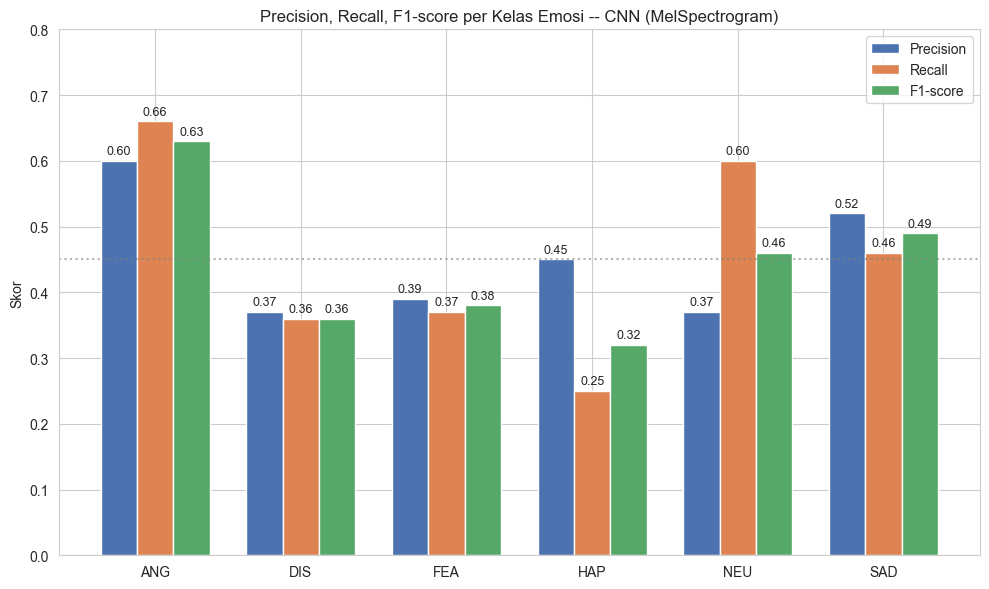


Visualisasi disimpan ke 'precision_recall_f1_per_kelas_cnn.png'

>> Gap Precision - Recall per kelas (mengukur arah bias model)
   Penjelasan: Nilai POSITIF (precision > recall) berarti model 'pelit' menebak kelas itu -- jarang menebak tapi kalau menebak cenderung benar (kasus HAP). Nilai NEGATIF (recall > precision) berarti model 'boros' menebak kelas itu -- sering menebak ke kelas tersebut meski belum tentu benar (kasus NEU dan ANG).


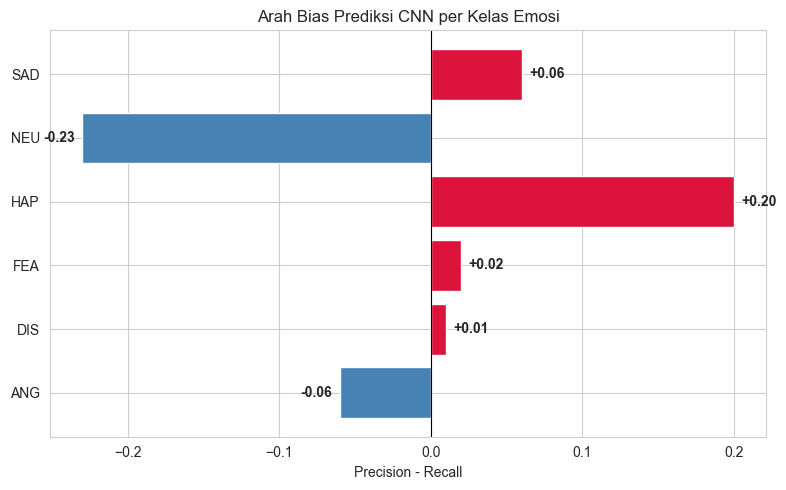


Visualisasi disimpan ke 'arah_bias_cnn_per_kelas.png'

Interpretasi singkat:
  ANG: gap=-0.06 -> model sering 'lari' ke kelas ini (recall>precision)
  DIS: gap=+0.01 -> relatif seimbang
  FEA: gap=+0.02 -> relatif seimbang
  HAP: gap=+0.20 -> model jarang menebak kelas ini (precision>recall)
  NEU: gap=-0.23 -> model sering 'lari' ke kelas ini (recall>precision)
  SAD: gap=+0.06 -> model jarang menebak kelas ini (precision>recall)


In [45]:
explain(
    "Precision vs Recall per kelas emosi -- CNN (data dari classification report)",
    "Bar berdampingan memperjelas pola bias model: ANG dan NEU punya recall "
    "tinggi (model 'condong' menebak ke arah dua kelas ini), sementara HAP "
    "punya pola sebaliknya -- precision lebih tinggi dari recall, artinya "
    "model jarang berani menebak HAP meski saat menebak cukup akurat."
)

classes = ["ANG", "DIS", "FEA", "HAP", "NEU", "SAD"]
precision = [0.60, 0.37, 0.39, 0.45, 0.37, 0.52]
recall    = [0.66, 0.36, 0.37, 0.25, 0.60, 0.46]
f1_score  = [0.63, 0.36, 0.38, 0.32, 0.46, 0.49]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, precision, width, label="Precision", color="#4c72b0")
bars2 = ax.bar(x, recall, width, label="Recall", color="#dd8452")
bars3 = ax.bar(x + width, f1_score, width, label="F1-score", color="#55a868")

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("Skor")
ax.set_title("Precision, Recall, F1-score per Kelas Emosi -- CNN (MelSpectrogram)")
ax.set_ylim(0, 0.8)
ax.legend()
ax.axhline(0.45, color="gray", linestyle=":", alpha=0.6, label="Accuracy keseluruhan")

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.2f}",
                ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("precision_recall_f1_per_kelas_cnn.png", dpi=150)
plt.show()
print("\nVisualisasi disimpan ke 'precision_recall_f1_per_kelas_cnn.png'")

# Highlight khusus: gap precision vs recall per kelas (mengukur arah bias)
explain(
    "Gap Precision - Recall per kelas (mengukur arah bias model)",
    "Nilai POSITIF (precision > recall) berarti model 'pelit' menebak kelas "
    "itu -- jarang menebak tapi kalau menebak cenderung benar (kasus HAP). "
    "Nilai NEGATIF (recall > precision) berarti model 'boros' menebak kelas "
    "itu -- sering menebak ke kelas tersebut meski belum tentu benar "
    "(kasus NEU dan ANG)."
)

gap = np.array(precision) - np.array(recall)
colors_gap = ["crimson" if g > 0 else "steelblue" for g in gap]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(classes, gap, color=colors_gap)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Precision - Recall")
ax.set_title("Arah Bias Prediksi CNN per Kelas Emosi")

for bar, g in zip(bars, gap):
    ax.text(g + (0.005 if g >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f"{g:+.2f}", va="center", ha="left" if g >= 0 else "right", fontweight="bold")

plt.tight_layout()
plt.savefig("arah_bias_cnn_per_kelas.png", dpi=150)
plt.show()
print("\nVisualisasi disimpan ke 'arah_bias_cnn_per_kelas.png'")
print("\nInterpretasi singkat:")
for cls, g in zip(classes, gap):
    arah = "model jarang menebak kelas ini (precision>recall)" if g > 0.05 else \
           "model sering 'lari' ke kelas ini (recall>precision)" if g < -0.05 else \
           "relatif seimbang"
    print(f"  {cls}: gap={g:+.2f} -> {arah}")